# <font color='blue' > 第2章 数据预处理</font>
<p style="line-height: 1.5;">
<details>
    <summary><font color='blue' size='4'>教学目标 </font></summary>
    <p style="line-height: 1.5;"> （1）通过数据预处理方法的学习，读者可在 NumPy 和 Pandas 的实际应用中激发对数据科学的兴趣，形成严谨、细致、精益求精的科学态度；    
</p>
    <p style="line-height: 1.5;">（2）在数据清洗过程中，检查、去重、填充和处理缺失值过程复杂，会遇到各种问题，要培养“迎难而上”的精神，不屈不挠地解决问题。</p>
</details>
<details>
    <summary><font color='blue' size='4'>教学内容</font></summary> 
    <p style="line-height: 1;"> 
        （1）NumPy 数据处理及运算。</p>
    <p style="line-height: 1;">
        （2）Pandas 基础。</p>
    <p style="line-height: 1;">
        （3）非数值数据转换。</p>
     <p style="line-height: 1;">
         （4）数据清洗。</p>     
 </details>

</p>

## <font color='blue' >2.1 NumPy 数据处理及运算
<p style="line-height: 1.5;"> 
NumPy 是 Python 的一个扩展程序库，支持<font color='red'>高维数组和矩阵运算</font>；同时，其提供了<font color='red'>针对数组运算的数学函数库</font>。</p>
<p style="line-height: 1.5;"> NumPy 的前身 Numeric 最早是由 JimHugunin 与其他协作者共同开发的。2005年，Travis Oliphant 在 Numeric 中结合了另一个同性质的程序库—— Numarray 的特色，并加入了其他要扩展的内容，形成现在的 NumPy。NumPy 为开源代码，由许多协作者共同维护开发。
</p>
 NumPy 是一个运行速度非常快的数学库，主要用于数组计算。
    
 **NumPy 主要包含：**
 
- 一个强大的 **N 维数组对象 ndarray**。
- 高效的**广播功能函数**。
- **整合 C/ C++/ Fortran 代码的工具包**。
- 实用的**线性代数、傅里叶变换、随机数生成等功能**。

### <font color='blue' >2.1.1  NumPy安装
<p style="line-height: 1.5;"> 
    
 Anaconda 中已经默认安装了 NumPy，其版本与 Anaconda 版本有关，除非特别说明，本章中代码片段的执行均在 Jupyter Notebook 上实现。</p>
 <p>
 安装 Anaconda 后，可以通过**属性 \_\_version\_\_ 查看 NumPy 的版本**：
</p>

In [1]:
import numpy as np
np.__version__

'1.21.6'

<p style="line-height: 1.5;"> 

在命令行窗口，可通过如下命令**更新 NumPy 版本：**</p>

>pip install --upgrade numpy

### <font color='blue' >2.1.2  创建 N 维数组
<p style="line-height: 1.5;">     
    NumPy 中的 N 维数组对象 ndarray 是<font color='red'>用于存放同类型元素的多维数组，元素索引自 0 开始</font>。由于 ndarray 是数组，所以 ndarray 中的每个元素在内存中都具有相同的存储大小。</p>
    
**ndarray 内部**由以下内容组成:
- **数据指针**：一个指向实际数据的指针。
- **数据类型（dtype）**：用于描述数组中元素的数据类型，表示每个元素所占的字节数，如整型（int32、int64）、浮点型（float16、float32、float64）、复数（complex64、complex128）及布尔型（bool）等。
- **维度（shape）**：一个表示数组形状的元组，表示数组各维度的大小。
- **跨度（strides）**：表示从当前维度前进到下一维度的当前位置所需“跨过”的字节数。

<p style="line-height: 1.5;">   
在 NumPy 中，数据存储于一个均匀连续的内存块中。可以这么理解，NumPy 将多维数组在内部<font color='red'>以一维数组的方式存储</font>，只要知道<font color='red'>每个元素所占的字节数及每个维度中元素的个数，就可以快速定位到任意维度的任意一个元素</font>。</p>

#### <font color='blue' >2.1.2.1  numpy.ndarray()
<p style="line-height: 1.5;">  
    <font color='red'>numpy.ndarray() 是 ndarray 类的构造函数</font>，返回一个 ndarray 对象，其是具有固定大小项的多维同质数组。
</p>
    
**numpy.ndarray() 函数的格式**如下：
    
>class numpy.ndarray(shape, dtype=float, buffer=None, offset=0, strides=None, ...)

其中，参数 dtype 描述数组中每个元素的格式（字节顺序、在内存中占用的字节数），它可以是整数、浮点数等。

下述代码片段展示了**底层 ndarray 构造函数的使用**:

In [10]:
np.ndarray(shape=(2,2), dtype=float, order='F')

array([[1., 4.],
       [2., 8.]])

<p style="line-height: 1.5;">  
上述代码使用默认构造函数创建了一个 ndarray 对象，其数组元素是<font color='red'>随机数值</font>。</p>
<p style="line-height: 1.5;"> 

**使用 numpy.ndarray() 函数创建一个多维整型数组**：</p>

In [11]:
np.ndarray((2,), buffer = np.array([1,2,3]), offset=np.int_().itemsize, dtype = int)

array([2, 3])

numpy.ndarray() 用起来<font color='red'>相对较麻烦、更低层</font>，NumPy 提供了一系列<font color='red'>创建 ndarray 对象的函数，numpy.array() </font>就是其中一种，其使用起来更方便。

#### <font color='blue' >2.1.2.2  numpy.array()
    
<p style="line-height: 1.5;"> 创建一个 ndarray 对象，只需调用 numpy.array() 函数，其格式如下：</p>

>numpy.array(object,dtype=None,copy=True,order=None,subok=False,ndmin=0)

**使用 numpy.array() 函数将列表数据变换成 ndarray：**

In [13]:
li=[1,2,3]
test = np.array(li)
print(li)
print('li的数据类型为：',type(li))
print(test)
print('test的数据类型为：',type(test))

[1, 2, 3]
li的数据类型为： <class 'list'>
[1 2 3]
test的数据类型为： <class 'numpy.ndarray'>


<details>
    <summary><font color='blue' size='3'>代码解析</font></summary> 
在上述代码片段中，使用 type() 函数返回其数据类型，变量 li 的输出是[1, 2, 3]，数据类型是列表（list）；test 的输出是 [1 2 3]，数据类型是 numpy 多维数组（'numpy.ndarray'）。
    
**注意：** list 打印显示是[1, 2, 3]；而 ndarray 打印显示则是[1 2 3]，中间没有逗号分割。
</details>

<p style="line-height: 1.5;"> 
NumPy 支持比 Python 更多种类的数值类型。

**通过 dtype 参数可设定数组元素的数据类型：**
</p>

In [14]:
a = [1, 2, 3]
b = np.array(a, dtype=np.float_)
# 或者
b = np.array(a, dtype=float)
print(b)
print(b.dtype)
print(type(b[0]))

[1. 2. 3.]
float64
<class 'numpy.float64'>


numpy.ndarray 的 dtype 和 shape 属性在前面已有详细描述。

下面**解释 strides 的含义：**

In [15]:
ls = [[[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12]], [[13, 14, 15, 16], [17, 18, 19, 20], [21, 22, 23, 24]]]
a = np.array(ls, dtype=int)
print(a.dtype)
print(a.strides)

int32
(48, 16, 4)


<details>
    <summary><font color='blue' size='3'>strides 解析</font></summary> 
上述代码片段定义了一个三维数组，dtype 为 int，int 占4字节。第一维度，从元素 1 到元素 13 ，间隔 12 个元素，总字节数为 48；第二维度，从元素 1 到元素 5，间隔 4 个元素，总字节数为 16；第三维度，从元素 1 到元素 2，间隔 1 个元素，总字节数为 4。因此，跨度为(48, 16, 4)。
</details>
<p style="line-height: 1.5;"> 

当需要一个数组对象的副本时，通过 **copy 参数**来实现：
</p>

In [16]:
a = np.array([1, 2, 3])
b = np.array(a, copy=True)
a[0] = 0
print(a)
print(b)

[0 2 3]
[1 2 3]


<p style="line-height: 1.5;"> 
上述代码片段中，经过 a[0] = 0 操作后，数组 a 和 b 的值不同，说明<font color='red'>虽然 b 是 a 的副本，但两者是不同的对象</font>。

在下述代码片段中，通过<font color='red'>设置 copy = False，a 的改变同时引起了 c 的改变</font>，说明数组 a 和 c 指向的是同一个对象：
</p>

In [18]:
a = np.array([1, 2, 3])
c = np.array(a, copy=False)
a[0] = 0
print(a)
print(c)

[0 2 3]
[0 2 3]


在 numpy.array() 函数中，可以通过 **ndmin 参数指定数组的最小维数**：

In [6]:
a = np.array([1, 2, 3])
d= np.array(a, ndmin=2)
print("d:",d)
e = np.array([[[1, 2, 3]]])
f= np.array(e, ndmin=2)
print("f:",f)

d: [[1 2 3]]
f: [[[1 2 3]]]


In [7]:
f.shape


(1, 1, 3)

<details>
    <summary><font color='blue' size='3'>代码解析</font></summary> 
<p style="line-height: 1.5;"> 
以上是使用 numpy.array() 函数构造 ndarray 对象的常用方法。由上述代码片段可以看出：</p>
    
- 在使用 ndmin 参数时，如果指定的 ndmin 值大于数组本身的维度，那么数组会自动扩展维度；
- 如果指定的 ndmin 值小于数组本身的维度，那么数组的维度不会发生改变。
</details>
<p style="line-height: 1.5;"> 

在创建数组对象后，可以**使用点运算符获取 ndarray 对象的属性值**，如数组对象的维度信息、元素的数据类型等。</p>

In [20]:
#一维数组
first = np.array([1.1, 2.0, 3.51])
#二维数组
second = np.array([[1,5],[2,6],[3,7]])
#获取数组形状，即数组维度和大小
print('first.shape:',first.shape)
print('second.shape:',second.shape)
#数组的维度数
print('first.ndim:',first.ndim)
print('second.ndim：',second.ndim)
#元素数据类型
print('first.dtype：',first.dtype)
print('second.dtype：',second.dtype)
#元素个数
print('first.size：',first.size)
print('second.size：',second.size)

first.shape: (3,)
second.shape: (3, 2)
first.ndim: 1
second.ndim： 2
first.dtype： float64
second.dtype： int32
first.size： 3
second.size： 6


<details>
    <summary><font color='blue' size='3'>代码解析</font></summary> 
在上述代码片段中，使用 numpy.array() 函数创建了两个不同的多维数组，分别命名为 first 和 second。

- 通过 ndarray 的 <font color='red'>shape 属性得到数组对象的维度和大小</font>。
- 通过 <font color='red'>ndim 属性得到数组的维度数</font>。从结果可以看出，first 是有 3 行数值的一维数组；second 是形状为(3,2)的二维数组，即具有 3 行 2 列元素的数组。
- 通过 <font color='red'>dtype 属性得到元素的数据类型</font>。从结果可以看出，first 数组元素的数据类型为浮点型 float64，second 数组元素的数据类型为整型 int32。
- 通过 <font color='red'>size 属性得到数组内元素的个数</font>。从结果可以看出，first 数组有 3 个元素，second 数组有 6 个元素。
</details>

#### <font color='blue' >2.1.2.3  numpy.arange()</font>
<p style="line-height: 1.5;"> 
    
除了使用 numpy.array() 函数创建多维数组外，还经常<font color='red'>使用 numpy.arange() 函数创建数值有规律的数组</font>。函数 numpy.arange() 类似于 Python 中的 range() 函数，通过**指定起始值、终止值和步长来创建一维数组**，并返回一个 ndarray 对象。</p>
<p style="line-height: 1.5;"> 
    numpy.arange() 函数的格式如下：</p>

>numpy.arange(start, stop, step, dtype)

<p style="line-height: 1.5;"> 
在 numpy.arange() 函数中，start 表示起始值，默认为 0；stop 表示终止值，需要注意终止值不包含于数组中；step 表示步长，默认为 1，该值可以为负数。
</p>
<p style="line-height: 1.5;"> 

下述代码片段**创建了一个线性序列数组**，数组内的元素从 0 开始，到 20 终止，步长设置为 4：
</p>

In [21]:
np.arange(0,20,4)

array([ 0,  4,  8, 12, 16])

函数 numpy.arange() 还可以<font color='red'>通过 dtype 属性设定输出数组的数据类型</font>。
<p style="line-height: 1.5;"> 
 
这里创建一个从 10 开始到 20 终止，步长为 2 的数组，**元素的数据类型设定为 float**：
</p>

In [22]:
np.arange(10,20,2, dtype = float) 

array([10., 12., 14., 16., 18.])

#### <font color='blue' >2.1.2.4  numpy.linspace()
<p style="line-height: 1.5;"> 
 
函数 numpy.arange() 创建的是一个由等差数列构成的一维数组（也称等差数组），numpy.linspace() 函数也可用于创建等差数组。两者都需要通过 start 和 stop 指定数组元素的生成范围，<font color='red' >区别是 numpy.arange() 函数可以指定生成元素间的步长，而 numpy.linspace() 函数需要指定生成元素的个数</font>。</p>
<p style="line-height: 1.5;">
numpy.linspace() 函数的格式如下：
</p>
    
>numpy.linspace(start,stop,num=50,endpoint=True,retstep=False,dtype=None)

现在使用 **numpy.linspace() 函数创建一个包含 10 个均匀地分布在 0 和 1 之间的元素的数组**，代码片段如下：

In [23]:
np.linspace(0,1,10)

array([0.        , 0.11111111, 0.22222222, 0.33333333, 0.44444444,
       0.55555556, 0.66666667, 0.77777778, 0.88888889, 1.        ])

上述代码片段设置 start=0，stop=1，num=10（num 的默认值为 50），即生成的等差数组中的元素个数为 10。
<p style="line-height: 1.5;">
<font color='red' >numpy.linespace() 函数和 numpy.arrange() 函数不同的是，前者默认最终生成的数组中包含终止值 stop。</font>

- 在 numpy.linespace() 函数中，设 endpoint 的值为 True，表示生成数组包含 stop；
- 如果 endpoint 的值为 False，则生成的数组中不包含 stop。</p>
<p style="line-height: 1.5;">

下述代码片段**创建了一个具有 5 个元素的数组，生成范围从 100 到 200**，生成的数组内不包含终止值 200：

In [24]:
np.linspace(100,200,5,endpoint=False)

array([100., 120., 140., 160., 180.])

在 numpy.linespace() 函数中，参数 retstep 的默认值为 False，即不返回步长；
<p style="line-height: 1.5;">

<font color='red' >若设 retstep 的值为 True，则返回步长，且函数返回值类型为元组，其第一个元素是 numpy.ndarray（ndarray 对象），第二个元素是步长</font>：</p>

In [25]:
np.linspace(100, 200, 5, endpoint=False, retstep = True)  

(array([100., 120., 140., 160., 180.]), 20.0)

### <font color='blue' >2.1.3  NumPy 切片和索引
<p style="line-height: 1.5;"> 
        
<font color='red' >numpy.ndarray 中的数据可通过索引或切片进行访问和修改</font>，与 Python 中列表的切片操作一样。索引可正可负，若索引为正数，则表示从左往右切片，从 0 开始；若索引为负数，则表示从右往左切片，从 -1 开始，如图2-1所示。切片遵循左闭右开原则，即包含起始值，不包含终止值。

[](attachment:image2-1.png)
<img src = attachment:image2-1.png width=300>

<div style="text-align: center;">图2-1 元素位置索引</div>

numpy.ndarray 可基于下标索引，通过内置的 **slice() 函数**设置 start、stop 和 step 等参数实现切片，不包含 stop。
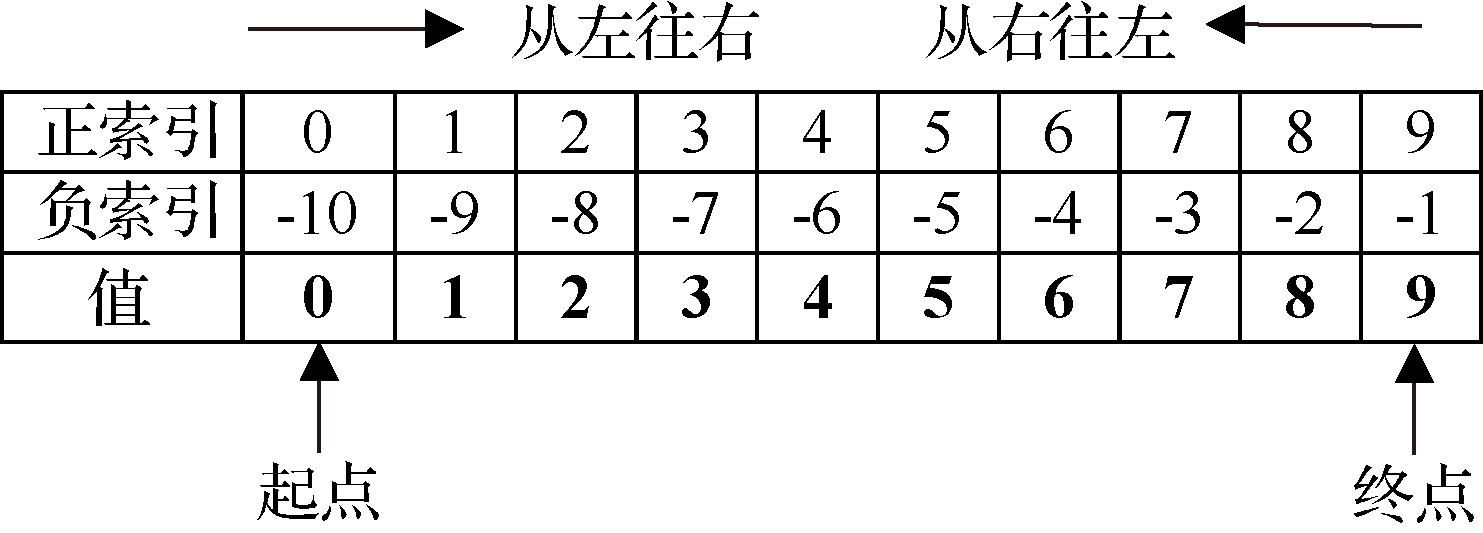

**例1. 一维数组切片**
<p style="line-height: 1.5;">
（1）通过函数 slice (10, 15, 2) 从数组 [0, 1, 2,…, 19] 中输出索引 10～15，步长为 2 的子数组：</p>

In [4]:
test=np.arange(20)
s=slice(10,15,2)  
test[s]

array([10, 12, 14])

<p style="line-height: 1.5;">

（2）使用以**冒号分隔的切片参数 start:stop:step** 可以实现相同的操作。
</p>

<p>在下述代码片段中，step = -2，表示从右往左对原数组进行切片，间隔值为 2。</p>

In [27]:
test=np.arange(20)
p=test[19:10:-2]  
p

array([19, 17, 15, 13, 11])

**例2. 多维数组切片和访问**
<p style="line-height: 1.5;"> 
多维数组的切片仅需分别设定行和列的切片即可，如下述代码所示。</p>

>首先创建一个 3×3 的二维数组test，通过行列索引 test[2,2] 访问数组中第 3 行第 3 列的数据。通过切片 test[1:]可以获取 test 第 1 行之后的所有数据；通过 test[2:3,1] 可以获取第 3 行第 2 列的数据，即[5]；通过 test[:,1:2] 可以获取第 2 列数据。

In [28]:
test=np.array([[1,2,3],[3,4,5],[4,5,6]])
print("test=\n",test)
#访问某数据
print("test[2,2]=",test[2,2])
#取第1行之后的数据  
print("test[1:]=\n",test[1:])
#取第3行到第2列的数据行
print("test[2:3,1]=",test[2:3,1])
#取第3列行到第2列的数据
print("test[:,1:2]=\n",test[:,1:2])

test=
 [[1 2 3]
 [3 4 5]
 [4 5 6]]
test[2,2]= 6
test[1:]=
 [[3 4 5]
 [4 5 6]]
test[2:3,1]= [5]
test[:,1:2]=
 [[2]
 [4]
 [5]]


### <font color='blue' >2.1.4  NumPy 数组操作</font> 
    
#### <font color='blue' >2.1.4.1  改变数组形状
<p style="line-height: 1.5;">  
    
在 Python 运算中，有时需要将数组中的数据重编排，<font color='red' >numpy.reshape() 函数在不改变数据的条件下，可以修改数组的形状（维度和大小）</font>。
numpy.reshape() 函数的格式如下：

>numpy.reshape(arr, newshape, order='C')

下面**创建一个 0 到 8 的一维数组，将其输出为 3×3 的二维数组：**


In [8]:
a = np.arange(9)
print ('原始数组为：',a)
b = a.reshape(3,3)
print ('修改后的数组：')
print(b)

原始数组为： [0 1 2 3 4 5 6 7 8]
修改后的数组：
[[0 1 2]
 [3 4 5]
 [6 7 8]]


在上述代码片段中，数组 a 和 b 分别表示两个不同形状的数组。
<p style="line-height: 1.5;"> 

下面**分别修改数组 a 和数组 b 中某个元素的值，观察数组 a 和 b 有什么变化。**

In [30]:
a[0] = -10
print("a=",a)
print("b=",b)

a= [-10   1   2   3   4   5   6   7   8]
b= [[-10   1   2]
 [  3   4   5]
 [  6   7   8]]


In [31]:
b[2,0] = -20
print("a=",a)
print("b=",b)

a= [-10   1   2   3   4   5 -20   7   8]
b= [[-10   1   2]
 [  3   4   5]
 [-20   7   8]]


- 修改数组 a 中某个元素的值，数组 a 和 b 中对应位置的元素都会改变；
- 同样，修改数组 b 中某个元素的的值，a 中对应位置的元素也做相应改变。

这是因为 <font color='red' >numpy.reshape() 函数返回的是原数组的引用</font>，除形状跟原数组不一样外，元素内容与原数组共享。
<p style="line-height: 1.5;"> 

**常用的改变数组形状的方法还有 resize() 函数**。resize() 函数不会返回任何新的数组，而是在原数组的基础上进行形状的改变，它可以对原数组进行缩放，即削减原数组元素个数或以指定值添加新元素。
</p>

In [32]:
a = np.arange(9)
b = a.resize(3,3)
print ('a=',a)
print ('b=',b)

a= [[0 1 2]
 [3 4 5]
 [6 7 8]]
b= None


在上述代码片段中，可以看出 resize() 函数没有返回值，它直接修改原数组 a 的形状。reshape() 函数会返回一个形状与原数组形状不同的新数组，而且其元素个数一定与原数组的元素个数相同。
<p style="line-height: 1.5;"> 

此外，**直接修改数组的 shape 属性也能改变数组形状**，只需设置 shape 为一个想要的维度和大小即可。代码示例如下：</p>

In [34]:
a.shape=(3,3)
a

array([[0, 1, 2],
       [3, 4, 5],
       [6, 7, 8]])

#### <font color='blue' >2.1.4.2  添加新数据
当需要在原数组基础上添加新数据时，numpy.append() 函数是一个很好的选择。<font color='red' >numpy.append() 函数在数组的末尾添加值</font>，并根据数组的形状从不同维度添加，生成一个新数组。
<p style="line-height: 1.5;"> 
    numpy.append() 函数的格式如下：</p>

>numpy.append(arr, values, axis=None)

参数 axis 的默认值为 None，表示元素数据横向添加，返回一维数组。需要注意的是，<font color='red' >输入数组 values 的维度必须和原数组 arr 匹配，否则将生成 ValueError</font>。
<p style="line-height: 1.5;"> 

下面创建一个二维数组 [[1,2,3],[4,5,6]]，并通过 **append() 函数添加数据：**

In [15]:
a=np.array([[1,2,3],[4,5,6]])
b=np.append(a, [7,8,9])
b
print(a)

[[1 2 3]
 [4 5 6]]


由上述代码片段可见，numpy.append() 函数完成追加操作后，返回一维数组。通过<font color='red' >设置 axis=0 或 axis=1 可分别实现在原数组行或列维度上的添加</font>。

**例1．沿着数组 a 的 0 轴追加数组 [7,8,9]**

In [36]:
np.append(a, [[7,8,9]],axis=0)

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

**例2．沿着数组 a 的 1 轴添加数组 [7,8,9] 和 [10,11,12]**

In [37]:
np.append(a, [[7,8,9],[10,11,12]],axis=1)

array([[ 1,  2,  3,  7,  8,  9],
       [ 4,  5,  6, 10, 11, 12]])

<details>
    <summary><font color='blue' size='3'>代码解析</font></summary> 

- 在numpy.append() 函数中，axis=0 表示在原数组下面添加行向量，需要注意添加的数据列数应与原数组的列数相同；
- axis=1 表示在原数组的列方向上添加数据，即将数据加在原数组的右边，需要注意添加的数据行数应与原数组的行数相同。
</details>

#### <font color='blue' >2.1.4.3  数组去重</font>
<p style="line-height: 1.5;">    
    <font color='red' >如果需要去除数组中的重复元素，numpy.unique() 函数可以轻松实现。</font>numpy.unique() 函数的格式如下：

>numpy.unique(arr, return_index, return_inverse, return_counts)

- arr 参数表示输入数组（如果不是一维数组，则数据会展开）;
- return_index 参数用于返回新数组元素在原数组中的索引首位置;
- return_inverse 参数用于返回原数组元素在新数组中的位置;
- return_counts 参数用于返回新数组中的元素在原数组中出现的次数。

下述代码片段展示了 **numpy.unique() 函数的常见应用**：

In [4]:
test = np.array([3, 1, 2, 2, 3, 1, 4, 5, 5])
unique_values = np.unique(test)  # 获取唯一值数组
print("unique_values=",unique_values)
# 获取唯一值的索引数组
unique_indices = np.unique(test, return_index=True)
print("unique_indices=",unique_indices)
# 获取逆向索引数组，用于还原原始数组
inverse_indices = np.unique(test, return_inverse=True)
print("inverse_indices=",inverse_indices)
# 获取唯一值的出现次数数组
value_counts = np.unique(test, return_counts=True)
print("value_counts =",value_counts)

unique_values= [1 2 3 4 5]
unique_indices= (array([1, 2, 3, 4, 5]), array([1, 2, 0, 6, 7], dtype=int64))
inverse_indices= (array([1, 2, 3, 4, 5]), array([2, 0, 1, 1, 2, 0, 3, 4, 4], dtype=int64))
value_counts = (array([1, 2, 3, 4, 5]), array([2, 2, 2, 1, 2], dtype=int64))


#### <font color='blue' >2.1.4.4  数组转置
<p style="line-height: 1.5;"> 
    在矩阵运算中，经常需要对矩阵进行转置操作，可理解为将二维数组的行列互换。<font color='red' >numpy.ndarray.T 和 numpy.transpose() 函数均可以对多维数组进行单轴或多轴的转置操作</font>。</p>
<p style="line-height: 1.5;">
    
**numpy.ndarray.T 的示例代码片段**如下。
    
**例1．一维数组转置**

In [42]:
a = np.array([1, 2, 3, 4, 5])
b = a.T
print(b)

[1 2 3 4 5]


**例2．二维数组转置**

In [43]:
c = np.array([[1, 2, 3], [4, 5, 6]])
d = c.T
print(d)

[[1 4]
 [2 5]
 [3 6]]


**例3．多维数组转置**

In [44]:
e = np.array([[[1, 2, 3, 4]], [[9, 7, 8, 9]]])
print(e.shape)
f = e.T
print(f.shape)
print(f) 

(2, 1, 4)
(4, 1, 2)
[[[1 9]]

 [[2 7]]

 [[3 8]]

 [[4 9]]]


<p style="line-height: 1.5;"> 
在上述代码片段中，numpy.ndarray.T 属性会返回转置后的新数组，原数组不会改变。</p>
<p>函数 numpy.transpose() 具有同样的转置功能，它还可以重新排列数组的维度顺序，其格式如下：</p>

>numpy.transpose(arr, axes=None)

参数 axes 用于指定数组新的维度顺序。
<p style="line-height: 1.5;"> 

下面，**分别使用 numpy.ndarray.transpose() 和 numpy.transpose() 两个函数改变数组的维度顺序**，并返回新数组：
</p>

In [45]:
e=np.arange(15).reshape(1,3,5)
print("转置前：\n",e.shape,"\n",e)
f = e.transpose()
print("默认转置后：\n",f.shape)
#numpy.ndarray.transpose()方法
g=e.transpose(2,0,1) 
print("设定维度转置后：\n",g.shape)
# numpy.transpose() 方法
h=np.transpose(e,axes=(1,0,2))
print("设定维度转置后：\n",h.shape,"\n",h)

转置前：
 (1, 3, 5) 
 [[[ 0  1  2  3  4]
  [ 5  6  7  8  9]
  [10 11 12 13 14]]]
默认转置后：
 (5, 3, 1)
设定维度转置后：
 (5, 1, 3)
设定维度转置后：
 (3, 1, 5) 
 [[[ 0  1  2  3  4]]

 [[ 5  6  7  8  9]]

 [[10 11 12 13 14]]]


#### <font color='blue' >2.1.4.5  广播机制
<p style="line-height: 1.5;"> 
    在 NumPy 中，<font color='red' >数组有一种广播机制，针对两个不同形状的数组进行加、减、乘、除运算时，需要将数组调整为统一的维度形状后进行运算。</font></p>
<p>
    下面是一个数组和一个整数相乘的例子：</p>

In [46]:
a = np.array([1, 2, 3])
b = 2
a * b 

array([2, 4, 6])

<p style="line-height: 1.5;"> 
在上述代码片段中，整数 b 需要扩展成 [2, 2, 2] 后和数组 a 做乘法。
</p>
<p>
下述代码片段是两个不同维度的数组相加的例子：
 </p>

In [6]:
a = np.array([[1],[10],[20]])
b = np.array([0, 1, 2])
a+b

array([[ 1,  2,  3],
       [10, 11, 12],
       [20, 21, 22]])

<p style="line-height: 1.5;"> 
数组 a 和 b 的形状分别为 (3, 1) 和 (1, 3)，按广播规则取两个数组中每个维度的最大值，最后应该是 (3, 3)，扩展和加法过程如图2-2所示。</p>

[](attachment:image2-2.png)
<img src = attachment:image2-2.png width=300>
<div style="text-align: center;">图2-2 扩展和加法过程</div>

<p style="line-height: 1.5;"> 
需要注意的是，不是所有不同形状的数组都可以做运算，广播机制有一定的规则。</p>
<p style="line-height: 1.5;"> 
<font color='red' >两个形状不相同的数组，只有两个数组的每一维度都相同，或者其中一个数组的某一维度为 1，两个数组才会进行广播并运算，否则会产生 ValueError:</font></p>
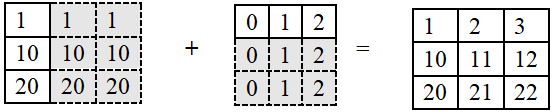

In [7]:
c = a+b
d = np.array([[0, 1, 2],[1, 1, 1]])
print(c+d)

ValueError: operands could not be broadcast together with shapes (3,3) (2,3) 

<font color='red' >函数 numpy.broadcast() 可根据输入数组的形状自动执行广播操作</font>，其格式如下：

>numpy.broadcast( *args )

\*args 是输入的数组对象，函数的参数数量可变。
<p>
    
下述代码片段中，**使用 numpy.broadcast() 函数完成数组广播，实现了加法操作：**
</p>

In [9]:
x = np.array([[1], [2], [3]])
y = np.array([4, 5, 6])
b = np.broadcast(x, y)
print(b.shape)
c = np.empty(b.shape)
c.flat = [i+j for (i, j) in b]
print(c)

(3, 3)
[[5. 6. 7.]
 [6. 7. 8.]
 [7. 8. 9.]]


<details>
    <summary><font color='blue' size='3'>代码解析</font></summary> 

- numpy.empty() 函数创建了一个指定形状（shape）和数据类型（dtype）且未初始化的数组；
- numpy.ndarray.flat 是一个返回数组元素的迭代器。
</details>
<p style="line-height: 1.5;"> 
<font color='red' >numpy.broadcast_to() 函数可以将数组广播为一个新的形状</font>，其格式如下：</p>

>numpy.broadcast_to(array, shape, subok=False)

在下述示例代码片段中，函数 broadcast_to() 的 shape 参数值为 (3, 3)，表示原数组 x 广播后生成的新数组的形状为 (3, 3)。

In [48]:
x = np.array([1,2,3])
y = np.broadcast_to(x, (3, 3))
y

array([[1, 2, 3],
       [1, 2, 3],
       [1, 2, 3]])

#### <font color='blue' >2.1.4.6  数组的扩展
<p style="line-height: 1.5;"> 
    <font color='red' >函数 numpy.expand_dims() 通过在指定位置插入新的轴来扩展数组</font>，其格式如下：</p>

>numpy.expand_dims(a, axis)

- a 是扩展前的原数组;
- axis 是扩展后的数组中新轴出现的位置。
<p style="line-height: 1.5;"> 

在下述代码片段中，分别**设定 axis=0、axis=1 和 axis=2来扩展数组：**</p>

In [49]:
x = np.array(([1, 2], [3, 4]))
print("原数组：\n",x.shape,"\n",x)
y1 = np.expand_dims(x, axis=0)
print("axis=0扩展后维度：",y1.shape)
print("新数组：\n",y1)

y2 = np.expand_dims(x, axis=1)
print("axis=1扩展后维度：",y2.shape)
print("新数组：\n",y2)

y3 = np.expand_dims(x, axis=2)
print("axis=2扩展后维度：\n",y3.shape)
print("新数组：\n",y3)

原数组：
 (2, 2) 
 [[1 2]
 [3 4]]
axis=0扩展后维度： (1, 2, 2)
新数组：
 [[[1 2]
  [3 4]]]
axis=1扩展后维度： (2, 1, 2)
新数组：
 [[[1 2]]

 [[3 4]]]
axis=2扩展后维度：
 (2, 2, 1)
新数组：
 [[[1]
  [2]]

 [[3]
  [4]]]


与 numpy.expand_dims() 函数相反，<font color='red' >numpy.squeeze() 函数用于从给定数组形状中删除维度为 1 的部分或全部维度</font>，其格式如下：

>numpy.squeeze(arr, axis)

- 如果没有设置 axis 参数，那么 numpy.squeeze() 函数会删除维度为 1 的所有维度；
- 若指定轴上的维度大于 1 ，则产生 ValueError。
<p style="line-height: 1.5;"> 
示例代码片段如下：</p>

In [50]:
x = np.array([[[0], [1], [2]]])
print(x.shape)
print(np.squeeze(x).shape)
print(np.squeeze(x, axis=0).shape)
print(np.squeeze(x, axis=2).shape)
np.squeeze(x, axis=1).shape

(1, 3, 1)
(3,)
(3, 1)
(1, 3)


ValueError: cannot select an axis to squeeze out which has size not equal to one

#### <font color='blue' >2.1.4.7  数组合并和拼接
<p style="line-height: 1.5;"> 
    <font color='red' >函数 numpy.stack() 的作用是将一系列数组沿指定轴合并</font>，其格式如下：
</p>
  
>numpy.stack(arrays, axis=0, out=None, *, dtype=None, casting='same_kind')

参数 arrays 按指定轴 axis 合并，如果 axis=0，则将沿第一个维度合并；如果 axis=-1，则将沿最后一个维度合并。
<p style="line-height: 1.5;">

下述代码片段**对两个一维数组进行合并，合并后会有两个维度**（注意：axis=-1 时的结果和 axis=1 时的结果相同）：</p>

In [51]:
a = np.array([1,2,3])
b = np.array([4,5,6])
print("axis = 0时：\n",np.stack((a,b),0))
print("axis = 1时：\n",np.stack((a,b),axis=1))

axis = 0时：
 [[1 2 3]
 [4 5 6]]
axis = 1时：
 [[1 4]
 [2 5]
 [3 6]]


<p style="line-height: 1.5;">
<font color='red' >numpy.hstack() 和 numpy.vstack() 两个函数是 numpy.stack() 函数的变体。</font>前者实现数组的水平堆叠，后者实现数组的垂直堆叠。
</p>
<p style="line-height: 1.5;">示例代码片段如下：</p>

In [52]:
a = np.array([[1, 2], [3, 4]])
b = np.array([[5, 6], [7, 8]])
print('水平堆叠：')
c = np.hstack((a, b))
print(c)
print('垂直堆叠：')
d = np.vstack((a, b))
print(d)

水平堆叠：
[[1 2 5 6]
 [3 4 7 8]]
垂直堆叠：
[[1 2]
 [3 4]
 [5 6]
 [7 8]]


<p style="line-height: 1.5;">
<font color='red' >numpy.concatenate() 函数可以一次完成多个数组的拼接</font>，与 numpy.append() 函数相比，它的效率更高，适合大规模的数组拼接，其格式如下：</p>

>numpy.concatenate((a1, a2, ...), axis=0, out=None, dtype=None...)

- (a1, a2, ...)是除对应轴之外具有相同形状的数组序列；
- axis 是数组序列沿其拼接的轴，如果 axis=None，则在使用前将数组展开。

<p style="line-height: 1.5;">
示例代码片段如下：</p>

In [53]:
a = np.array([[1, 2], [3, 4]])
b = np.array([[5, 6]])
print("axis=0:")
print(np.concatenate((a, b), axis=0))
print("axis=1:")
print(np.concatenate((a, b.T), axis=1))
print("axis=None:")
print(np.concatenate((a, b), axis=None))

axis=0:
[[1 2]
 [3 4]
 [5 6]]
axis=1:
[[1 2 5]
 [3 4 6]]
axis=None:
[1 2 3 4 5 6]


#### <font color='blue' > 2.1.4.8  数组分割
<p style="line-height: 1.5;">
前面介绍了数组合并和拼接，接下来介绍数组分割。
    <font color='red' >numpy.split() 函数可以沿指定轴将数组分割成多个子数组</font>，其格式如下：</p>

>numpy.split(array, indices_or_sections, axis=0)

<p style="line-height: 1.5;">
array 表示要分割的数组，indices_or_sections 用于指定平均分割数组的段数或指定分割点的索引位置。</p>

- 若 indices_or_sections 的值是整数 N，则该数组将沿指定轴划分为 N 个维度相等的数组；
- 如果indices_or_sections 的值是有序整数组成的一维数组，则数组内的整数值表示数组沿指定轴分割的索引位置。

<p>在进行数组分割操作时，axis 的默认值为 0，表示沿第一维度进行分割。</p>

**例1. 沿指定轴划分为多个维度相等的数组：**

In [58]:
x = np.arange(9.0)
print(x)
np.split(x, 3)

[0. 1. 2. 3. 4. 5. 6. 7. 8.]


[array([0., 1., 2.]), array([3., 4., 5.]), array([6., 7., 8.])]

**例2. 沿指定轴按索引进行不等分割：**

In [59]:
x = np.arange(9.0)
np.split(x, [3, 5, 6, 10])

[array([0., 1., 2.]),
 array([3., 4.]),
 array([5.]),
 array([6., 7., 8.]),
 array([], dtype=float64)]

<details>
    <summary><font color='blue' size='3'>代码解析</font></summary> 
<p style="line-height: 1.5;"> 
在上述代码片段中，axis=0，indices_or_sections=[3, 5, 6, 10]，表示数组 x 被分为 x[:3]、x[3:5]、x[5:6]、x[6:9] 和 x[ ] 五个子数组。由于 indices_or_sections 中的索引值 10 超出了原数组 x 指定轴上的维度 9，因此返回数据中包含一个空数组。</p>
</details>
<p style="line-height: 1.5;"> 

<font color='red' >numpy.array_split() 函数也可以实现数组分割</font>，其格式如下：</p>

>numpy.array_split(ary, indices_or_sections, axis=0)

<p style="line-height: 1.5;"> 
<font color='red'>与numpy.split() 唯一的区别是，numpy.array_split() 可以按段数进行不等分割</font>，即允许参数 indices_or_sections 的值为指定轴上的不等分整数列表。
若指定轴上维度为L，indices_or_sections 取整数 n，则返回 n 个子数组，分别是维度为 L// n + 1 的 L% n 个子数组和维度为 L// n 的 (n - L% n) 个子数组。</p>
<p style="line-height: 1.5;"> 
下述代码片段指定轴上的维度为 9，indices_or_sections = 4，由于 9%4 = 1，9//4 = 2，因此函数返回 1 个维度为 3 的子数组和 3 个维度为 2 的子数组：</p>

In [60]:
x = np.arange(9)
np.array_split(x, 4)

[array([0, 1, 2]), array([3, 4]), array([5, 6]), array([7, 8])]

<p style="line-height: 1.5;"> 
函数 numpy.hsplit()、numpy.vsplit() 和 numpy.dsplit() 分别用于数组的水平分割、垂直分割和深度分割，它们都是 numpy.split() 函数的变体。前三者的不同之处仅在于指定轴不同，其<font color='red'>分别对应 numpy.split() 函数中 axis=1、axis=0 和 axis=2 的作用</font>。</p>
<p style="line-height: 1.5;"> 

**（1）函数 numpy.hsplit() 用于数组分割时，数组总是沿着第二个轴拆分，与数组维度无关。**示例代码片段如下：

In [61]:
x = np.arange(8.0).reshape(2, 2, 2)
print("原数组:\n",x)
print("水平分割后：\n",np.hsplit(x, 2))

原数组:
 [[[0. 1.]
  [2. 3.]]

 [[4. 5.]
  [6. 7.]]]
水平分割后：
 [array([[[0., 1.]],

       [[4., 5.]]]), array([[[2., 3.]],

       [[6., 7.]]])]


**（2）函数 numpy.vsplit() 用于数组分割时，数组总是沿着第一个轴拆分，与数组维度无关。**示例代码片段如下：

In [62]:
x=np.arange(4).reshape(2,2)
print(x)
print("垂直平均分割:\n",np.vsplit(x,2))
print("沿索引垂直分割:\n",np.vsplit(x,np.array([1,2])))

[[0 1]
 [2 3]]
垂直平均分割:
 [array([[0, 1]]), array([[2, 3]])]
沿索引垂直分割:
 [array([[0, 1]]), array([[2, 3]]), array([], shape=(0, 2), dtype=int32)]


**（3）函数 numpy.dsplit() 用于数组分割时，如果数组维度大于或等于 3，则始终沿着第三个轴拆分。**示例代码片段如下：

In [63]:
arr = np.array([[[1, 2], [3, 4]], [[5, 6], [7, 8]]])
np.dsplit(arr, 2)

[array([[[1],
         [3]],
 
        [[5],
         [7]]]), array([[[2],
         [4]],
 
        [[6],
         [8]]])]

### <font color='blue' > 2.1.5  数学函数</font>
#### <font color='blue' > 2.1.5.1  数组的基本运算</font>
<p style="line-height: 1.5;"> 
NumPy 通用函数的使用方式非常自然，因为它用到了 Python 原生的算术运算符，即标准的加、减、乘、除等：</p>

In [64]:
a=np.arange(0,5)
print("a+5=",a+5)#加法运算
print("a-5=",a-5)#减法运算
print("a×5=",a*5)#乘法运算
print("a÷5=",a/5)#除法运算

a+5= [5 6 7 8 9]
a-5= [-5 -4 -3 -2 -1]
a×5= [ 0  5 10 15 20]
a÷5= [0.  0.2 0.4 0.6 0.8]


<p style="line-height: 1.5;"> 
<font color='red'>由于广播的特性，基本运算在数组所有元素上进行。</font>
</p>
<p>
    
NumPy 对基本运算进行了封装，如**函数 numpy.add() 是加法运算符的一个封装器：**
    </p>

In [65]:
print("a+5=",a+5,'=',np.add(a,5))

a+5= [5 6 7 8 9] = [5 6 7 8 9]


NumPy 中封装的算术运算符如表2-1所示。
<div style="text-align: center;">表2-1 NumPy中封装的算术运算符</div>

| 运算符 | 通用函数 | 描述 |
|---|---|---|
|+|numpy.add()|加法运算（1+2=3）|
|-|numpy.subtract()|减法运算（2-1=1）|
|\*|numpy.multiply()|乘法运算（2\*3=6）|
|/|numpy.divide()|除法运算（3/2=1.5）|
|\*\*|numpy.power()|指数运算（2 ** 3=8）|
|%|numpy.mod()|取模（余数）运算（9%2=1）|


#### <font color='blue' > 2.1.5.2  绝对值与取反</font>
<p style="line-height: 1.5;"> 
<font color='red' >函数 numpy.abs() 返回数据的绝对值。</font>在数据分析和科学计算中，该函数经常用于计算数据的离散程度或两个数之间的差距等。示例代码片段如下：

In [66]:
a=-3
test=np.array([1, 2, 0, -1, -2]) 
print('np.abs:',np.abs(a))
print('np.abs:',np.abs(test))

np.abs: 3
np.abs: [1 2 0 1 2]


<p style="line-height: 1.5;"> 
<font color='red' >函数 numpy.negative() 用于返回数组中每个数值的相反数</font>，如果参数中有字符等非数值数据，则函数会报错。</p>
示例代码片段如下：

In [67]:
test=np.array([1.1, 2, 0, -1, -2]) 
np.negative(test)

array([-1.1, -2. , -0. ,  1. ,  2. ])

#### <font color='blue' > 2.1.5.3  三角函数
<p style="line-height: 1.5;"> 
    
NumPy 提供了大量的通用函数，如**常用的三角函数 sin()、cos() 和 tan() 等**。示例代码片段如下：

In [68]:
test=np.array([0,30,45,60,90])
test=test*np.pi/180
print ('通过乘 pi/180 转化为弧度：')
print (test)
print ('数组中角度的正弦值：')
print (np.sin(test))
print ('数组中角度的余弦值：')
print (np.cos(test))
print ('数组中角度的正切值：')
print (np.tan(test))

通过乘 pi/180 转化为弧度：
[0.         0.52359878 0.78539816 1.04719755 1.57079633]
数组中角度的正弦值：
[0.         0.5        0.70710678 0.8660254  1.        ]
数组中角度的余弦值：
[1.00000000e+00 8.66025404e-01 7.07106781e-01 5.00000000e-01
 6.12323400e-17]
数组中角度的正切值：
[0.00000000e+00 5.77350269e-01 1.00000000e+00 1.73205081e+00
 1.63312394e+16]


<p style="line-height: 1.5;"> 

NumPy 还提供了 **arcsin()、arccos() 和 arctan() 等反三角函数**，函数结果可以<font color='red' >通过 numpy.degrees() 函数将弧度转换为角度</font>。</p>
示例代码片段如下：

In [69]:
print('反正弦arcsin：',np.degrees(np.arcsin(np.sin(test))))
print('反余弦arccos：',np.degrees(np.arccos(np.cos(test))))
print('反正切arctan：',np.degrees(np.arctan(np.tan(test))))

反正弦arcsin： [ 0. 30. 45. 60. 90.]
反余弦arccos： [ 0. 30. 45. 60. 90.]
反正切arctan： [ 0. 30. 45. 60. 90.]


#### <font color='blue' > 2.1.5.4  指数及对数</font>
<p style="line-height: 1.5;"> 
指数运算和对数运算也是 NumPy 中常用的计算函数。<font color='red' >函数 numpy.power() 可以实现指数操作</font>，其格式如下：</p>

>numpy.power(x1,x2,/,out=None,*,where=True, casting='same_kind', order='K'..) 

- 第一数组 x1 中的元素为底，第二数组 x2 中的元素为指数，x1 和 x2 必须可广播为相同的形状;
- 需要注意的是，当整数类型的数据为底时，若指数为负值，则产生 ValueError。

<p style="line-height: 1.5;"> 
示例代码片段如下：</p>

In [70]:
x1 = np.arange(6)
print("x1:\n",x1)
y1 = np.power(x1, 3)
print("y1:\n",y1)
x2 = [1.0, 2.0, 3.0, 3.0, 2.0, 1.0]
y2 = np.power(x1,x2)
print("y2:\n",y2)
x3 = np.array([[1, 2, 3, 3, 2, 1], [1, 2, 3, 3, 2, 1]])
y3 = np.power(x1,x3)
print("y3:\n",y3)

x1:
 [0 1 2 3 4 5]
y1:
 [  0   1   8  27  64 125]
y2:
 [ 0.  1.  8. 27. 16.  5.]
y3:
 [[ 0  1  8 27 16  5]
 [ 0  1  8 27 16  5]]


**** 运算符和 numpy.power() 函数的作用一样**，如下所示：

In [71]:
x2 = np.array([1, 2, 3, 3, 2, 1])
x1 = np.arange(6)
x1 ** x2

array([ 0,  1,  8, 27, 16,  5], dtype=int32)

**当负值为底、非整数值为指数时，运算结果为 nan**。示例代码片段如下：

In [72]:
x3 = np.array([-1.0, -4.0])
with np.errstate(invalid='ignore'):
      p = np.power(x3, 1.5)
p

array([nan, nan])

若想**获得复数结果**，则可将输入数据强制转换为复数类型，或者将数据类型指定为 complex。
示例代码片段如下：

In [73]:
np.power(x3,1.5,dtype=complex)

array([-1.83697020e-16-1.j, -1.46957616e-15-8.j])

<p><font color='red' >对数函数是指数函数的逆运算，numpy.log() 和 numpy.log2() 函数实现对数运算，前者的底是 e，后者的底是 2。</font></p>
示例代码片段如下：

In [74]:
x = np.array([1,8,np.e**2,100])
y1 = np.log2(x)  #以2为底的对数运算
print(y1)
y2 = np.log(x)  #计算自然对数
print(y2)
y3 = np.log10(x)#以10为底的对数运算
print(y3)

[0.         3.         2.88539008 6.64385619]
[0.         2.07944154 2.         4.60517019]
[0.         0.90308999 0.86858896 2.        ]


**对数元组可以通过 numpy.power() 函数变换回原数组**，如下所示：

In [75]:
x = np.array([1,2,4,8])
np.power(2,np.log2(x))

array([1., 2., 4., 8.])

#### <font color='blue' > 2.1.5.5  取整函数</font>
<p style="line-height: 1.5;"> 
<font color='red' >函数 numpy.round()（同 numpy.around() ）可以将浮点型数据按给定的小数位四舍五入</font>，其格式如下：

>numpy.round(a, decimals=0, out=None)

decimals 参数为四舍五入后要保留的小数位数，其默认值为 0，具体用法如下：

In [77]:
a=np.array([5.2839,-1.747,0.25,2.0])
print(np.round(a))
print(np.round(a,2))
print(np.round(a,decimals=3))

[ 5. -2.  0.  2.]
[ 5.28 -1.75  0.25  2.  ]
[ 5.284 -1.747  0.25   2.   ]


<p style="line-height: 1.5;"> 
Python 中的内置函数 round() 也可以实现四舍五入，但其内部算法对于 64 位浮点型数据更准确，速度较慢。</p>

**函数 numpy.round() 和 round() 比较如下：**

In [3]:
x = np.round(16.055, 2)
print(x)
y = round(16.055,2)# =16.0549999999999997
print(y)

16.06
16.05


<p>

**numpy.trunc() 函数**用于计算输入数组元素的截断值，只保留小数点左边的整数。
    </p>
**numpy.rint() 函数**也返回数据的整数，但返回的是数据四舍五入后的整数，如下所示：

In [79]:
a = np.array([-1.7, -1.5, -0.2, 0.2, 1.5, 1.7, 2.0])
print(np.trunc(a))
print(np.rint(a))

[-1. -1. -0.  0.  1.  1.  2.]
[-2. -2. -0.  0.  2.  2.  2.]


<p>
    
此外，**numpy.floor() 函数**返回小于或等于输入数据的最大整数，即向下取整；</p>
**numpy.ceil() 函数**返回大于或等于输入数据的最小整数，即向上取整。示例代码片段如下：

In [80]:
a = np.array([-1.7, -1.5, -0.2, 0.2, 1.5, 1.7, 2.0])
print(np.floor(a))
print(np.ceil(a))

[-2. -2. -1.  0.  1.  1.  2.]
[-1. -1. -0.  1.  2.  2.  2.]


#### <font color='blue' >2.1.5.6  元素的连乘操作
<p style="line-height: 1.5;"> 
    <font color='red' >函数 numpy.prod() 用于计算数组中所有元素的乘积</font>，任意数组或矩阵都可以作为输入数据，其运算速度非常快，其格式如下：

>numpy.prod(a, axis=None, dtype=None, out=None, keepdims=<no value>...)

参数 axis 指定计算乘积的轴，其默认值为 None。
<p>
    在下述代码片段中，y1 是数组 a 中所有元素的乘积；y2 是数组 a 中第 2 列数据的乘积；y3 是数组 a 横轴上所有元素的乘积；y4 是数组 a 纵轴上所有元素的乘积：

In [81]:
a = np.array([[1., 2.], [3., 4.]])
y1 = np.prod(a)
print("y1=", y1)
y2 = np.prod(a[:,1])
print("y2=", y2)
y3 = np.prod(a, axis=1)
print("y3=", y3)
y4 = np.prod(a, axis=0)
print("y4=", y4)

y1= 24.0
y2= 8.0
y3= [ 2. 12.]
y4= [3. 8.]


需要注意的是，**空数组的 numpy.prod()** 运算的结果为 1：

In [76]:
np.prod([])

1.0

#### <font color='blue' >2.1.5.7  元素的累积乘积
<p style="line-height: 1.5;"> 
    <font color='red' > 函数 numpy.cumprod() 返回数组元素沿给定轴的累积乘积</font>，其格式如下：</p>

>numpy.cumprod(a, axis=None, dtype=None, out=None)

axis 的默认值为 None，即 numpy.cumprod() 函数默认计算展平后数组的乘积。
<p style="line-height: 1.5;"> 
在下述代码片段中，数组 b 为数组 a 进行累积乘积的结果，1、1×2、1×2×3、1×2×3×4 分别作为输出数组 b 的元素：</p>

In [82]:
a = np.array([1, 2, 3, 4])
b = np.cumprod(a)
b

array([ 1,  2,  6, 24], dtype=int32)

<p>由于累积乘积会使数组元素变得非常大，因此在使用 numpy.cumprod() 函数时，需要<font color='red' > 注意数据类型溢出问题，此时可以通过 dtype 参数指定最终数组的数据类型。</font></p>
<p style="line-height: 1.5;">

如**下述代码片段指定输出数组的数据类型为 np.float32：**

In [4]:
a = np.array([[1, 2, 3], [4, 5, 6]])
np.cumprod(a,dtype=np.float32)

array([  1.,   2.,   6.,  24., 120., 720.], dtype=float32)

<p style="line-height: 1.5;"> 
在使用 numpy.cumprod() 函数时，<font color='red' > 设置 axis=0 和 axis=1，可分别实现数组按列和按行进行累积乘积</font>。示例代码片段如下：</p>

In [84]:
print( np.cumprod(a, axis=0))
print("\n", np.cumprod(a, axis=1))

[[ 1  2  3]
 [ 4 10 18]]

 [[  1   2   6]
 [  4  20 120]]


#### <font color='blue' >2.1.5.8  获取元素符号
<p style="line-height: 1.5;">
    <font color='red' > 函数 numpy.sign() 是 NumPy 中获取元素符号（正负号）的函数</font>，可以将数组中每个元素转换为 1、0 或 -1。</p>
    
- 若元素为正数，则返回 1；
- 若元素为负数，则返回 -1；
- 若元素为 0，则返回 0。

<p style="line-height: 1.5;">
    函数 numpy.sign() 的用法如下：</p>

In [85]:
a = [-0.2, -1.1, 2, 0, 4.5, 0.0] 
np.sign(a)

array([-1., -1.,  1.,  0.,  1.,  0.])

#### <font color='blue' >2.1.5.9  元素的截取赋值
<p style="line-height: 1.5;">
    <font color='red' > 函数 numpy.clip() 可以对列表、数组、数据框等元素进行截取赋值</font>，返回一个新的数组，原数组不变，其格式如下：

>numpy.clip(a, a_min, a_max, out=None, \*\*kwargs)

- a_min：如果数组或数据框中的元素小于该值，则使用该值进行截取赋值。
- a_max：如果数组或数据框中的元素大于该值，则使用该值进行截取赋值。
- out：表示用来存储结果的输出数组，其默认值为 None。若 out = a，则表示将返回结果放置在数组 a 中，a 必须具有对应的形状。

<p style="line-height: 1.5;">

在函数 numpy.clip() 中，**当 a_min > a_max 时，返回的数组元素只有 a_min 和 a_max。**</p>

<p>在下述代码片段中，np.clip(a, 7, 1) 表示元素数值若比 7 小，则赋值 7；若大于或等于 1，则赋值 1：</p>

In [86]:
a = np.arange(10)
print("原始数组：",a)
print("clip后：",np.clip(a, 1, 8))
print("clip后：",np.clip(a, 7, 1))
b = np.clip(a, 3, 6, out=a)
print(b)
print(a)

原始数组： [0 1 2 3 4 5 6 7 8 9]
clip后： [1 1 2 3 4 5 6 7 8 8]
clip后： [7 7 7 7 7 7 7 1 1 1]
[3 3 3 3 4 5 6 6 6 6]
[3 3 3 3 4 5 6 6 6 6]


#### <font color='blue' >2.1.5.10  元素的差值计算
<p style="line-height: 1.5;">
    <font color='red' > numpy.diff() 函数用于计算数组或列表中沿给定轴的相邻元素之间的差值</font>，并返回一个新数组，其格式如下：

>numpy.diff(a,n=1,axis=-1,prepend=\< no value \>,append= \< no value \>)
    
- 返回的新数组中的差值由 out[i]=a[i+1]-a[i] 沿给定轴得出；
- 参数 n 表示执行差值计算的次数，其默认值为 1；
- 参数 axis 指定进行差分的轴，默认是在最后一个轴上进行差分。

**例1. 一维数组的差值运算**
<p>在下述代码片段中，y2 是在 y1 的基础上做差值运算的结果：</p>

In [87]:
x = np.array([1, 2, 4, 7, 0])
y1 = np.diff(x)#执行1次差值运算
print("y1:",y1)
y2 = np.diff(x, n=2)#执行2次差值运算
print("y2:",y2)

y1: [ 1  2  3 -7]
y2: [  1   1 -10]


**例2. 二维数组的差值运算**
<p>
对于二维数组，axis = 1 和 axis = -1 具有相同的作用。示例代码片段如下：</p>

In [88]:
x = np.array([[1, 3, 6, 10], [0, 5, 6, 8]])
y1 = np.diff(x)
print("y1:\n",y1)
y2 = np.diff(x, axis=0)#按列计算差值
print("y2:\n",y2)

y1:
 [[2 3 4]
 [5 1 2]]
y2:
 [[-1  2  0 -2]]


### <font color='blue' >2.1.6  统计函数</font>
<p style="line-height: 1.5;">
NumPy 提供了很多统计函数，用于从数组中查找最小值、最大值、百分位、标准差和方差等。</p>

#### <font color='blue' >2.1.6.1  求和、最小值和最大值</font>
<p style="line-height: 1.5;">
        
  **函数 numpy.sum() 用于计算数组中所有元素的和：**

In [89]:
test=np.array([1,2,3,4,5,6,7,8])
print('数组和计算方式1：',test.sum())
print('数组和计算方式2：',np.sum(test))

数组和计算方式1： 36
数组和计算方式2： 36


类似的有 **numpy.min() 和 numpy.max() 函数**，分别用于获取给定数组的最小值与最大值：

In [90]:
test=np.array([1,2,3,4,5,6,7,8])
print('最小值为：',np.min(test))
print('最大值为：',np.max(test))

最小值为： 1
最大值为： 8


#### <font color='blue' >2.1.6.2  中位数</font>
<p style="line-height: 1.5;">
    <font color='red' > 函数 numpy.median() 用于计算数组的中位数</font>。将一组数据按大小依次排列，中间位置的一个数据叫作这组数据的中位数，如果一组数据有偶数个，则通常取中间两个数值的平均值作为中位数。
numpy.median() 函数的格式如下：</p>

>numpy.median(a,axis=None,out=None,overwrite_input=False, keepdims=False)

参数 axis 的默认值为 None，表示将数组 a 展开成一维数组后取中位数。

**函数 numpy.median() 的用法如下：**

In [91]:
a = np.array([[10, 7, 4], [3, 2, 1]])
print(np.median(a))
print(np.median(a, axis=0))
print(np.median(a, axis=1))

3.5
[6.5 4.5 2.5]
[7. 2.]


#### <font color='blue' >2.1.6.3  算术平均值</font>
<p style="line-height: 1.5;">
<font color='red' > 函数 numpy.mean() 用于计算数组沿着指定轴的算术平均值</font>，默认返回值的数据类型为 float64。</p>
numpy.mean() 函数的格式如下：

>numpy.mean(a, axis=None, dtype=None, out=None,  where=\< no value \>...)

下述代码片段通过**设置参数 axis 的取值**，可依次对数组 a 求其所有元素的均值、按列求均值，以及按行求均值。

In [92]:
a = np.array([[1, 2, 3], [3, 4, 5]])
print(np.mean(a))#默认axis=None
print(np.mean(a, axis=0))
print(np.mean(a, axis=1))

3.0
[2. 3. 4.]
[2. 4.]


#### <font color='blue' >2.1.6.4  标准差</font>
<p style="line-height: 1.5;">
   <font color='red' >  函数 numpy.std() 用于沿指定轴计算数据的标准差。</font>标准差可以用来衡量一组数据的分散程度，标准差越大，表示数据分布越分散。</p>
numpy.std() 函数格式的如下：

>numpy.std(a, axis=None, dtype=None, out=None, ddof=0, mean=\< no value \>...)
    
**函数 numpy.std() 的示例**代码片段如下：

In [93]:
a = np.array([[1, 2], [3, 4]])
print('全局标准差为:',np.std(a))            
print('列标准差为:',np.std(a, axis=0))   
print('行标准差为:',np.std(a, axis=1)) 

全局标准差为: 1.118033988749895
列标准差为: [1. 1.]
行标准差为: [0.5 0.5]


#### <font color='blue' >2.1.6.5  方差</font>
<p style="line-height: 1.5;">
<font color='red' > 函数 numpy.var() 用于计算数组的方差。</font>方差描述了数据集的分布和离散程度，是统计分析中常用的一个重要指标，方差越大，数据点越分散。</p>
numpy.var() 函数的格式如下：

>numpy.var(a, axis=None, dtype=None, out=None, ddof=0, mean=\< no value \>...)

**numpy.var() 函数的示例**代码片段如下：

In [5]:
a = np.array([[1, 2], [3, 4]])
print('全局方差为:',np.var(a))            
print('列方差为:',np.var(a, axis=0))   
print('行方差为:',np.var(a, axis=1)) 

全局方差为: 1.25
列方差为: [1. 1.]
行方差为: [0.25 0.25]


#### <font color='blue' >2.1.6.6  百分位数</font>
<p style="line-height: 1.5;">
<font color='red' >函数 numpy.percentile() 用于计算指定轴上数组元素的第 n 个百分位数</font>，返回值为标量或数组，其格式如下：

>numpy.percentile(a,q,axis=None,out=None,overwrite_input=False...)

- 参数 a 可为数组或可被转换为数组的数据对象；
- q 为要计算的百分比，其值必须介于 0 和 100 之间（包括 0 和 100）；
- 参数 axis 用于确定计算百分位数的轴，其默认值为 None，表示计算数组 a 展开为一维数组后的百分位数。

示例代码片段如下：

In [95]:
a = np.array([[10, 7, 4], [3, 2, 1]])
print(np.percentile(a, 50))
print(np.percentile(a, [50,90]))
#按第1维度求百分比
print("axis = 0:",np.percentile(a, 50, axis=0))
#按第2维度求百分比
print("axis = 1:",np.percentile(a, 50, axis=1))

3.5
[3.5 8.5]
axis = 0: [6.5 4.5 2.5]
axis = 1: [7. 2.]


<p style="line-height: 1.5;">
在上述代码片段中，numpy.percentile(a, 50) 和 numpy.median(a) 等价，即数组 a 展开后的第 50 个百分位数是数组 a 的中位数。</p>
<p style="line-height: 1.5;">
<font color='red' >numpy.quantile() 和 numpy.percentile() 具有相同的作用</font>，可计算数据集中指定轴的分位数，两者的不同之处仅在于前者要计算的分位数的取值范围为 0～1。</p>
numpy.quantile() 函数的格式如下：

>numpy.quantile(a,q,axis=None,out=None,overwrite_input=False)

下述代码片段中的 **q = 0.25、q = 0.5 和 q = 0.75 分别对应第一四分位数、中位数和第三四分位数**：

In [96]:
a = np.array([[10, 7, 4], [3, 2, 1]])
#求四分位数
print(np.quantile(a, 0.25))
print(np.quantile(a, 0.5))
print(np.quantile(a, 0.75))
#按第1维度求中位数
print(np.quantile(a, 0.5, axis = 0 ))
#按第2维度求中位数
print(np.quantile(a, 0.5, axis = 1 ))

2.25
3.5
6.25
[6.5 4.5 2.5]
[7. 2.]


#### <font color='blue' >2.1.6.7  协方差和相关系数</font>
<p style="line-height: 1.5;">
    <font color='red' >函数 numpy.cov() 用来计算协方差，并返回一个协方差矩阵</font>，其格式如下：</p>
    
>numpy.cov(m, y=None, rowvar=True, bias=False, ddof=None, fweights=None...)

<p style="line-height: 1.5;">
协方差是一个度量两个变量的线性相关性的统计量，可以理解为两个变量一起变化的程度。两个变量同向变化时，协方差为正值，协方差数值越大，说明两个变量的同向程度越大。两个变量反向变化时，协方差为负值，协方差的绝对值越大，说明两个变量的反向程度越大。
<p>
    
下述代码片段展示了**一个二维数组的协方差计算：**
</p>

In [97]:
x = np.array([[0, 1, 2], [2, 1, 0]]).T
print(x)
np.cov(x)

[[0 2]
 [1 1]
 [2 0]]


array([[ 2.,  0., -2.],
       [ 0.,  0.,  0.],
       [-2.,  0.,  2.]])

**两个数组的协方差计算如下：**

In [98]:
x = [-2.1, -1,  4.3]
y = [3,  1.1,  0.12]
X = np.stack((x, y), axis=0)
print("cov(X)：\n",np.cov(X))
print("cov(x,y)：\n",np.cov(x, y))
print("cov(x)：\n",np.cov(x))

cov(X)：
 [[11.71       -4.286     ]
 [-4.286       2.14413333]]
cov(x,y)：
 [[11.71       -4.286     ]
 [-4.286       2.14413333]]
cov(x)：
 11.709999999999999


<p style="line-height: 1.5;">
在使用函数 numpy.cov() 计算协方差时，需要注意以下3点。</p>

- （1）变量矩阵的一行表示一个随机变量。
- （2）参数 bias 控制在进行协方差计算时除以 n-1 还是 n，若 bias=True，表示除以 n；若 bias=False，则表示除以 n - 1。
- （3）输出结果是一个协方差矩阵，results[i][j] 表示第 i 个随机变量与第 j 个随机变量的协方差。

<p style="line-height: 1.5;">
相关系数是一种特殊的协方差，其公式如下：</p>
<div style="text-align: center;"> $\rho=\frac{Cov(x,y)}{\sigma x\sigma y}$      （2-1）</div>

<p style="line-height: 1.5;">
    从式（2-1）中可以看出，相关系数等于 x、y 的协方差除以 x 的标准差和 y 的标准差。
因此，<font color='red' >相关系数可看作剔除了两个变量量纲的影响，标准化后的特殊协方差。</font></p>   

相关系数既可以反映两个变量变化时是同向的还是反向的，又消除了两个变量变化幅度的影响，它只是单纯**反映两个变量每单位变化时的相似程度**。</p>
    <font color='red' >函数 numpy.corrcoef() 用来计算相关系数矩阵</font>，其格式如下：

>numpy.corrcoef(x, y=None, rowvar=True, bias=\< no value \>, ddof=\< no value \>...)

- 函数返回值为相关系数矩阵，其元素介于 0 和 1 之间（包括 0 和 1）；
- results[i][j] 表示第 i 个随机变量与第 j 个随机变量的相关系数。

下述代码片段**分别计算二维数组的相关系数，以及两个不同数组之间的相关系数**，其中元素自己和自己的相关性最大，值为 1，因此，相关系数矩阵对角线的值全为 1，为对称矩阵。

In [3]:
a = np.array(([[0.77395605, 0.43887844, 0.85859792],
       [0.69736803, 0.09417735, 0.97562235],
       [0.7611397 , 0.78606431, 0.12811363]]))
b = np.array(([[0.45038594, 0.37079802, 0.92676499],
       [0.64386512, 0.82276161, 0.4434142 ],
       [0.22723872, 0.55458479, 0.06381726]]))
merged_array = np.concatenate((a,b), axis = 0)
res1 = np.corrcoef(a)
res2 = np.corrcoef(a, b)
res3 = np.corrcoef(merged_array)
print("np.corroef(a) : \n {}".format(res1))
print("The res2 equal to res3 is {}".format(np.array_equal(res2, res3)))
print("np.corroef(merged_array) : \n {}".format(res2))

np.corroef(a) : 
 [[ 1.          0.99256089 -0.68080987]
 [ 0.99256089  1.         -0.76492173]
 [-0.68080987 -0.76492173  1.        ]]
The res2 equal to res3 is True
np.corroef(merged_array) : 
 [[ 1.          0.99256089 -0.68080987  0.75008178 -0.934284   -0.99004057]
 [ 0.99256089  1.         -0.76492173  0.82502011 -0.97074098 -0.99981569]
 [-0.68080987 -0.76492173  1.         -0.99507202  0.89721356  0.77714685]
 [ 0.75008178  0.82502011 -0.99507202  1.         -0.93657855 -0.83571711]
 [-0.934284   -0.97074098  0.89721356 -0.93657855  1.          0.97517215]
 [-0.99004057 -0.99981569  0.77714685 -0.83571711  0.97517215  1.        ]]


NumPy 中常用的统计函数如表2-2所示。需要注意的是，大多数聚合函数都具有对 NaN 值的安全处理策略（NaN-safe），即计算时忽略所有缺失值。
<div style="text-align: center;">表2-2  NumPy 中常用的统计函数<div>
    
| 函数名称 | NAN 安全版本 | 描述 |
|:---|:---|:---|
|numpy.sum()|numpy.nansum|计算元素的和|
|numpy.prod()|numpy.nanprod|计算元素的积|
|numpy.mean()|numpy.nanmean|计算元素的平均值|
|numpy.std()|numpy.nanstd|计算元素的标准差|
|numpy.var()|numpy.nanvar|计算元素的方差|
|numpy.min()|numpy.nanmin|找出最小值|
|numpy.max()|numpy.nanmax|找出最大值|
|numpy.argmin()|numpy.nanargmin|找出最小值的索引|
|numpy.argmax()|numpy.nanargmax|找出最大值的索引|
|numpy.median()|numpy.nanmedian|计算元素的中位数|
|numpy.percentile()|numpy.nanpercentile|计算基于元素排序的统计值|
|numpy.any()|N/A|验证任何一个元素是否为真|
|numpy.all()|N/A|验证所有元素是否为真|

### <font color='blue' >2.1.7  排序函数</font>
<p style="line-height: 1.5;">
    <font color='red' >排序函数 numpy.sort() 可返回输入数组排序后的副本</font>，其格式如下：

>numpy.sort(a, axis=-1, kind, order)

- a 为要排序的数组；
- axis 为排序轴,默认值为 -1，表示沿最后的轴进行排序；
- kind 为排序方法，其默认值为 'quicksort'（快速排序），可选择 'mergesort'（归并排序）、'heapsort'（堆排序）等排序方法；
- order 多用于字段定义的数组（也称结构化数组），该参数取值为字段名的字符串或字符串列表，通过该参数指定要比较的第一字段、第二字段等，并且不需要指定所有字段，未指定字段仍将按它们在 dtype 中出现的顺序使用。
 
下述代码片段**对二维数组 test 进行排序，请注意 axis 参数的取值**。在函数 numpy.sort() 中，对于二维数组，axis=1 和 axis=-1 的结果相同，均表示按行排序；而 axis=0 则表示按列排序。

In [100]:
test=np.array([[4,3,5],[7,8,2],[6,1,10]])
print("原数组test=\n",test)
sort2=np.sort(test,axis=0)
print('排序axis=0:\n',sort2)
sort3=np.sort(test,axis=1)
print('排序axis=1:\n',sort3)

原数组test=
 [[ 4  3  5]
 [ 7  8  2]
 [ 6  1 10]]
排序axis=0:
 [[ 4  1  2]
 [ 6  3  5]
 [ 7  8 10]]
排序axis=1:
 [[ 3  4  5]
 [ 2  7  8]
 [ 1  6 10]]


下面创建一个**结构化数组**，通过设置 order 参数实现按字段排序：

In [101]:
dt = np.dtype([('name',  'S20'),('age',  int)]) 
a = np.array([("mary",21),("lily",25),("rain",17), ("anna",17)], dtype = dt)  
print ('原始数组是：')
print (a)
print ('按 name 排序：')
print (np.sort(a, order =  'name'))
print ('先按 age 排序，再按 name 排序：')
print (np.sort(a, order =  ['age','name']))

原始数组是：
[(b'mary', 21) (b'lily', 25) (b'rain', 17) (b'anna', 17)]
按 name 排序：
[(b'anna', 17) (b'lily', 25) (b'mary', 21) (b'rain', 17)]
先按 age 排序，再按 name 排序：
[(b'anna', 17) (b'rain', 17) (b'mary', 21) (b'lily', 25)]


**numpy.ndarray.sort() 与 numpy.sort()** 参数的功能完全一致，只是调用方式不同。示例代码片段如下：

In [102]:
a = np.array([[1,4],[6,2],[3,1]])
a.sort(axis=1)
a

array([[1, 4],
       [2, 6],
       [1, 3]])

**numpy.sort_complex() 函数**用于对复数数组进行排序，首先按实部排序，然后按虚部排序。示例代码片段如下：

In [103]:
np.sort_complex([1 + 2j, 2 - 1j, 3 - 2j, 3 - 3j, 3 + 5j])

array([1.+2.j, 2.-1.j, 3.-3.j, 3.-2.j, 3.+5.j])

### <font color='blue' >2.1.8  直方图函数</font>
<p style="line-height: 1.5;">

有时需要直观展示数据的位置状况、离散程度和分布形状，这时可以选择使用直方图。**直方图表示数据的概率分布，它用一系列宽度相等、高度不等的长条形来表示数据，其宽度代表组距，高度代表指定组距内的数据数量（频数）。**</p>

<font color='red' >函数 numpy.histogram() 用于计算数据集的直方图统计量</font>，其格式如下：

>numpy.histogram(a, bins=10, range=None, density=None, weights=None)

- 参数 a 为输入数组，在进行直方图统计量计算时，均展开为一维数组；
- 当 bins 为整数时，表示直方图上等宽的长条形数量（柱子数量、箱子数量），其默认值为 10；
- 当 bins 为单调递增数组时，数组内元素表示非等宽的长条形的边缘值；
- 参数 range 为 bin 的取值范围。

示例代码片段如下：

In [104]:
a = np.array([100,300, 400, 500, 600, 700, 800, 900, 1000])
np.histogram(a, bins=3)

(array([2, 3, 4], dtype=int32), array([ 100.,  400.,  700., 1000.]))

<details>
    <summary><font color='blue' size='3'>代码解析</font></summary> 
<p style="line-height: 1.5;"> 
在上述代码片段中，numpy.histogram() 函数返回一个包含两个数组的元组。array([2, 3, 4] , dtype=int64) 表示 3 个长条形的值（高度），array([100., 400., 700., 1000.] 表示长条形的边缘数值。</p>
    
- 第一个长条形边缘对应 [100, 400)，数组 a 中有 2 个数值；
- 第二个长条形边缘对应 [400,700)，数组 a 中有 3 个数值；
- 第三个长条形边缘对应 [700,1000]，数组 a 中有 4 个数值。

<p>需要注意的是，前两者是左闭右开的，最后一个长条形左右都是闭合的。</p>
</details>
<p style="line-height: 1.5;"> 
示例代码片段如下：

In [105]:
np.histogram([1, 2, 1, 0], bins=[0, 1, 2, 3])

(array([1, 2, 1], dtype=int32), array([0, 1, 2, 3]))

<p style="line-height: 1.5;">

**函数 numpy.histogram() 只返回直方图数据，绘图时需要使用 Matplotlib 库**，Matplotlib 库是 Python 的一个 2D 绘图库，详见第 7 章。</p>
<p>
下述代码片段利用 numpy.histogram() 函数的返回值，通过 bar() 函数完成绘图，如下所示。</p>

x:  [0.5, 1.5, 2.5]


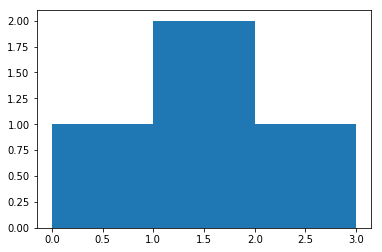

In [107]:
import matplotlib.pyplot as plt
hist, bin_edges = np.histogram([1,2,1,0],bins=[0, 1, 2, 3])
#求每个柱子的中心坐标 x
x = [(bin_edges[i]+bin_edges[i+1])/2 for i in range(len(bin_edges)-1)]  
print("x: ", x)
#每个柱子的高度 y
y = hist 
#每个柱子的宽度width
plt.bar(x, y,width=bin_edges[1]-bin_edges[0])  
plt.show()

上述操作等同于下述代码片段：

(array([1., 2., 1.]), array([0, 1, 2, 3]), <a list of 3 Patch objects>)

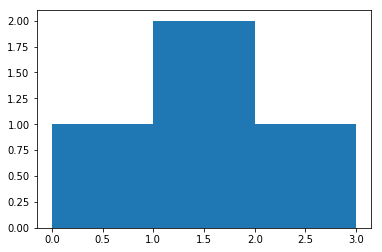

In [108]:
plt.hist([1, 2, 1, 0], bins=[0, 1, 2, 3])

<p style="line-height: 1.5;">
<font color='red' >
函数 numpy.histogram2d()  可计算两个数据样本的二维直方图</font>，其格式如下：

>numpy.histogram2d(x, y, bins=10, range=None, weights=None, density=None...)

- 参数 x 表示做直方图处理的第一维度数据；
- y 表示做直方图处理的第二维度数据；
- bins 表示两个维度上的长条形数量；
- 函数返回值为元组 (H, xedges, yedges)，其中，H 为样本 x 和 y 在直方图上两个维度的数据，xedges 为长条形沿第一维度的边缘数值，yedges 为长条形沿第二维度的边缘数值。

示例代码片段如下：

In [18]:
x = np.random.normal(2, 1, 100)
y = np.random.normal(1, 1, 100)
xedges = [0, 1, 3, 5]
yedges = [0, 2, 3, 4, 6]
np.histogram2d(x, y, bins=(xedges, yedges))

(array([[ 8.,  2.,  0.,  0.],
        [50., 15.,  2.,  0.],
        [ 7.,  1.,  0.,  0.]]), array([0, 1, 3, 5]), array([0, 2, 3, 4, 6]))

## <font color='blue' >2.2 Pandas基础</font>
<p style="line-height: 1.5;">
2.1节详细介绍了 NumPy 数组运算，numpy.ndarray 对象为 Python 数组提供了高效的存储和处理方法。Pandas 基于 NumPy 开发，可以与其他第三方科学计算支持库完美集成。接下来深入学习 Pandas。</p>
<p style="line-height: 1.5;">
Pandas 主要提供了<font color='red' >两种高效的数据结构——Series（一维数据）和 DataFrame（二维数据）</font>，用于直观地处理关系型、标记型数据。Pandas 不仅为带各种标签的数据提供了便利的存储结构，还实现了<font color='red' >非数值数据转换、缺失值处理、数据去重、数据合并连接、数据分组等多种操作</font>，非常实用。</p>

### <font color='blue' >2.2.1  数据快捷加载</font>
<p style="line-height: 1.5;">

Anaconda 中默认安装 Pandas，其版本与 Anaconda 版本有关。</p>

**在 Jupyter Notebook 中导入 Pandas 库，一般使用 pd 做别名，可通过 \_\_version\_\_ 查看 Pandas 版本：**

In [1]:
import pandas as pd 
pd.__version__

'1.1.5'

<p style="line-height: 1.5;">

在命令行窗口中，可以使用如下命令**更新 Pandas 版本**：

>pip install--upgrade pandas

<p style="line-height: 1.5;">
Pandas 库中有最方便的、功能完备的数据加载函数可以从资源库直接下载数据集后读取或利用 URL 直接下载数据集。<font color='red' >数据的来源有多种形式： SQL 数据库、CSV 或 Excel 文件、原始 HTML、图像、JSON 文件等。</font>Pandas 提供了 read_csv()、read_excel() 等多种函数，可加载不同类型数据集，如表2-3所示。</p>
<div style="text-align: center;">表2-3 Pandas加载数据的函数</div>

| 函数 | 说明 | 
| :---: | :---: |
|pd.read_csv(filename)| 读取CSV文件 |
|pd.read_excel(filename)| 读取Excel文件 |
|pd.read_sql(query, connection_object)| 从SQL数据库读取数据 |
|pd.read_json(json_string)|从JSON字符串中读取数据|
|pd.read_html(url)|从HTML页面读取数据|

<p style="line-height: 1.5;">

由于 SQL、JSON、HTML、HDFS、Excel 等类型的数据集不经常使用，因此，如何加载和处理它们，留给读者自己学习，这里主要介绍如何处理 CSV 文件。
本书**以 property-data.csv 数据集为例**，请登录华信教育资源网（www.hxedu.com.cn） 下载。</p>
<p>
    <font color='red' >使用 read_csv() 函数读取数据（默认逗号作为分隔符），返回结果为 Pandas 数据框（DataFrame）。</font></p>
read_csv() 函数的格式如下：

>read_csv(filepath_or_buffer,sep=',', header='infer', names=None, ......)


In [2]:
test_data=pd.read_csv('property-data.csv')
test_data

,PID,ST_NUM,ST_NAME,OWN_OCCUPIED,NUM_BEDROOMS,NUM_BATH,SQ_FT
0,100001000.0,104.0,PUTNAM,Y,3,1,1000
1,100002000.0,197.0,LEXINGTON,N,3,1.5,--
2,100003000.0,NaN,LEXINGTON,N,NaN,1,850
3,100004000.0,201.0,BERKELEY,12,1,NaN,700
4,NaN,203.0,BERKELEY,Y,3,2,1600
5,100006000.0,207.0,BERKELEY,Y,NaN,1,800
6,100007000.0,NaN,WASHINGTON,NaN,2,HURLEY,950
7,100008000.0,213.0,TREMONT,Y,1,1,NaN
8,100009000.0,215.0,TREMONT,Y,na,2,1800


<p style="line-height: 1.5;">
数据加载时可修改列名，同时只读取文件开头的 4 行数据，操作方法有以下两种。</p>

**第一种，在加载文件时，直接通过 read_csv() 函数进行参数修改：**

In [3]:
test_data=pd.read_csv('property-data.csv',names=['ID编号','街道号码','街道名称','是否有人入住','房间数量','浴室数量','面积'],nrows = 4,header = 0)
test_data

,ID编号,街道号码,街道名称,是否有人入住,房间数量,浴室数量,面积
0,100001000,104.0,PUTNAM,Y,3.0,1.0,1000
1,100002000,197.0,LEXINGTON,N,3.0,1.5,--
2,100003000,NaN,LEXINGTON,N,NaN,1.0,850
3,100004000,201.0,BERKELEY,12,1.0,NaN,700


<details>
    <summary><font color='blue' size='3'>代码解析</font></summary> 

- 设置 names 的值，其值为 test_data 所有中文列名组成的列表，以达到修改标题名的目的；
- header 的值为 0，表示读取文件时显示列名；
- nrows = 4 表示只读取文件开头的 4 行数据。
</details>  
<p style="line-height: 1.5;">

**第二种，加载数据后，通过 rename() 函数修改加载好的数据文件。**</p>

rename() 函数的格式如下：
>DataFrame.rename(mapper=None,index=None,columns=None,inplace=False...) 

- inplace 的默认值为 False，表示创建并返回重命名后的副本；
- 若 inplace = True，则在原数据框上进行修改。

示例代码片段如下：

In [9]:
test_data.rename(columns = {'PID':'ID编号','ST_NUM':'街道号码','ST_NAME':'街道名称','OWN_OCCUPIED':'是否有人入住','NUM_BEDROOMS':'房间数量','NUM_BATH':'浴室数量','SQ_FT':'面积'}, inplace=True)
test_data.head(4)

,ID编号,街道号码,街道名称,是否有人入住,房间数量,浴室数量,面积
0,100001000.0,104.0,PUTNAM,Y,3,1,1000
1,100002000.0,197.0,LEXINGTON,N,3,1.5,--
2,100003000.0,NaN,LEXINGTON,N,NaN,1,850
3,100004000.0,201.0,BERKELEY,12,1,NaN,700


<p style="line-height: 1.5;">

数据加载后，可以通过 **shape 属性查看 test_data 的维度和大小**。</p>

In [3]:
test_data=pd.read_csv('property-data.csv')
test_data.shape

(9, 7)

<p style="line-height: 1.5;">
test_data 是一个 9 行 7 列的数据框。如果还想了解一下数据，则<font color='red'>可通过 head() 或 tail() 函数分别查看前几行或最后几行数据</font>。</p>

**head() 函数的示例代码片段**如下：

In [120]:
test_data.head(3)

,ID编号,街道号码,街道名称,是否有人入住,房间数量,浴室数量,面积
0,100001000,104.0,PUTNAM,Y,3.0,1.0,1000
1,100002000,197.0,LEXINGTON,N,3.0,1.5,--
2,100003000,NaN,LEXINGTON,N,NaN,1.0,850


**tail() 函数的示例代码片段**如下：

In [13]:
test_data.tail(2)

,PID,ST_NUM,ST_NAME,OWN_OCCUPIED,NUM_BEDROOMS,NUM_BATH,SQ_FT
7,100008000.0,213.0,TREMONT,Y,1,1,NaN
8,100009000.0,215.0,TREMONT,Y,na,2,1800


<p><font color='red'>若函数 head() 和 tail() 中不写参数，则默认返回前 5 行与后 5 行数据。</font></p>

此外，**info() 函数可以快速浏览 test_data 的摘要信息：**

In [4]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PID           8 non-null      float64
 1   ST_NUM        7 non-null      float64
 2   ST_NAME       9 non-null      object 
 3   OWN_OCCUPIED  8 non-null      object 
 4   NUM_BEDROOMS  7 non-null      object 
 5   NUM_BATH      8 non-null      object 
 6   SQ_FT         8 non-null      object 
dtypes: float64(2), object(5)
memory usage: 632.0+ bytes


<p style="line-height: 1.5;">
<font color='red'>调用 info() 函数，除了可以得到数据集的大小、列名及数据类型，还可以获取每列非空值（non-null）的数量。</font>在数据文件 property-data.csv 中，PID、ST_NUM 两列的数据类型是 float64；其他列的数据类型是 object，可以理解为非数字类型。</p>

<p><font color='red'>
函数 describe() 用于显示数值框中数值型列的基本统计信息，如计数、方差、均值、最小值、最大值等；非数字类型不参与计算。</font></p>
示例代码片段如下：

In [5]:
test_data.describe()

,PID,ST_NUM
count,8.000000e+00,7.000000
mean,1.000050e+08,191.428571
std,2.927700e+03,39.080503
min,1.000010e+08,104.000000
25%,1.000028e+08,199.000000
50%,1.000050e+08,203.000000
75%,1.000072e+08,210.000000
max,1.000090e+08,215.000000


### <font color='blue' >2.2.2  Pandas 数据结构</font>

#### <font color='blue' >2.2.2.1  Series </font>
<p style="line-height: 1.5;">   

Pandas 中的 Series 结构类似一维数组，**由一组数据值和一组索引组成**。索引默认为整数，从 0 开始依次递增，索引与数据值一一对应。Series 结构可以保存任何数据类型，如整数、字符串、浮点数、 Python 对象等。</p>
<p style="line-height: 1.5;">
<font color='red' >pandas.Series() 函数可创建一个 Series 对象</font>，其格式如下：</p>

>pandas.Series(data, index, dtype, name, copy)

参数 data 可以是列表、字典和多维数组等。下面**用列表和数组创建一个 Series 实例：**

In [6]:
a=[11,22,33]
test1=pd.Series(a)
test1

0    11
1    22
2    33
dtype: int64

In [9]:
names=np.array(['Mary','Lily','James'])
test2=pd.Series(names)
test2

0     Mary
1     Lily
2    James
dtype: object

<p style="line-height: 1.5;"> 
在使用列表或数组创建 Series 对象时，<font color='red' >如果没有指定索引，则索引从 0 开始，左侧一列 0, 1, 2,…是默认索引（也称隐式索引），右侧一列是 Series 的实际数据</font>，“dtype: int64”表示 test1 中的数据类型为整型。</p>
<p style="line-height: 1.5;"> 

我们可以**根据索引读取数据**，读取方式与列表类似，如下所示：</p>

In [10]:
print('test1索引为0的值为：',test1[0])
print('test2索引为2的值为：',test2[2])

test1索引为0的值为： 11
test2索引为2的值为： James


<p style="line-height: 1.5;">

下述代码片段**通过字典建立了一个 Series 对象**。</p>
<p>
与使用列表或数组创建 Series 略有不同，<font color='red' >通过字段建立的 Series 的索引是字典中的键，在左侧；字典中的值为 Series 中的数据，在右侧。</font>通过 test[语文]、test[数学] 可以访问不同索引的数值。示例代码片段如下：

In [11]:
dict = {"语文":80,"数学":88,"英语":100}
test = pd.Series(dict)
test

语文     80
数学     88
英语    100
dtype: int64

<p style="line-height: 1.5;">

**使用 index 参数指定 Series 对象的索引，实现显示索引**，并通过索引读取数据。</p>

<font color='red' >需要注意的是，在同时访问多个索引的数值时，需要将索引放于列表中。</font>例如，test[['b','c']] 可同时访问 'b' 和 'c' 对应的数值，代码片段如下：

In [13]:
a=[11,22,33]
test=pd.Series(a,index=['a','b','c'])
print(test)
print('索引为a的值为：',test['a'])
print('索引为b、c的值为：\n',test[['b','c']])

a    11
b    22
c    33
dtype: int64
索引为a的值为： 11
索引为b、c的值为：
 b    22
c    33
dtype: int64


#### <font color='blue' >2.2.2.2  DataFrame</font>
<p style="line-height: 1.5;"> 

<font color='red' >DataFrame 是一个表格型的数据结构，类似于二维数组，它含有一组有序的列，每列所有元素的数据类型（数字、字符串、布尔型值等）必须相同，不同列元素的数据类型可以不同。</font>DataFrame 既有**行索引（行标签）**，又有**列索引（列标签）**，它的每列数据都可以看作一个 Series 结构，其关系如图2-4所示。

[](attachment:image2-4.png)
<img src = attachment:image2-4.png width=300>
<div style="text-align: center;">图2-4 DataFrame和Series</div>

<p style="line-height: 1.5;"> 
pandas.DataFrame()函数的格式如下：

>pandas.DataFrame(data, index, columns, dtype, copy)

- 参数 data 是输入数据，可以是 ndarray、Series、map、list 和 dict 等类型；
- index 是索引，又叫行标签；
- columns 为列标签，默认为 RangeIndex（0, 1, 2,…, n）。

这里**通过二维数组创建一个 DataFrame 对象：**
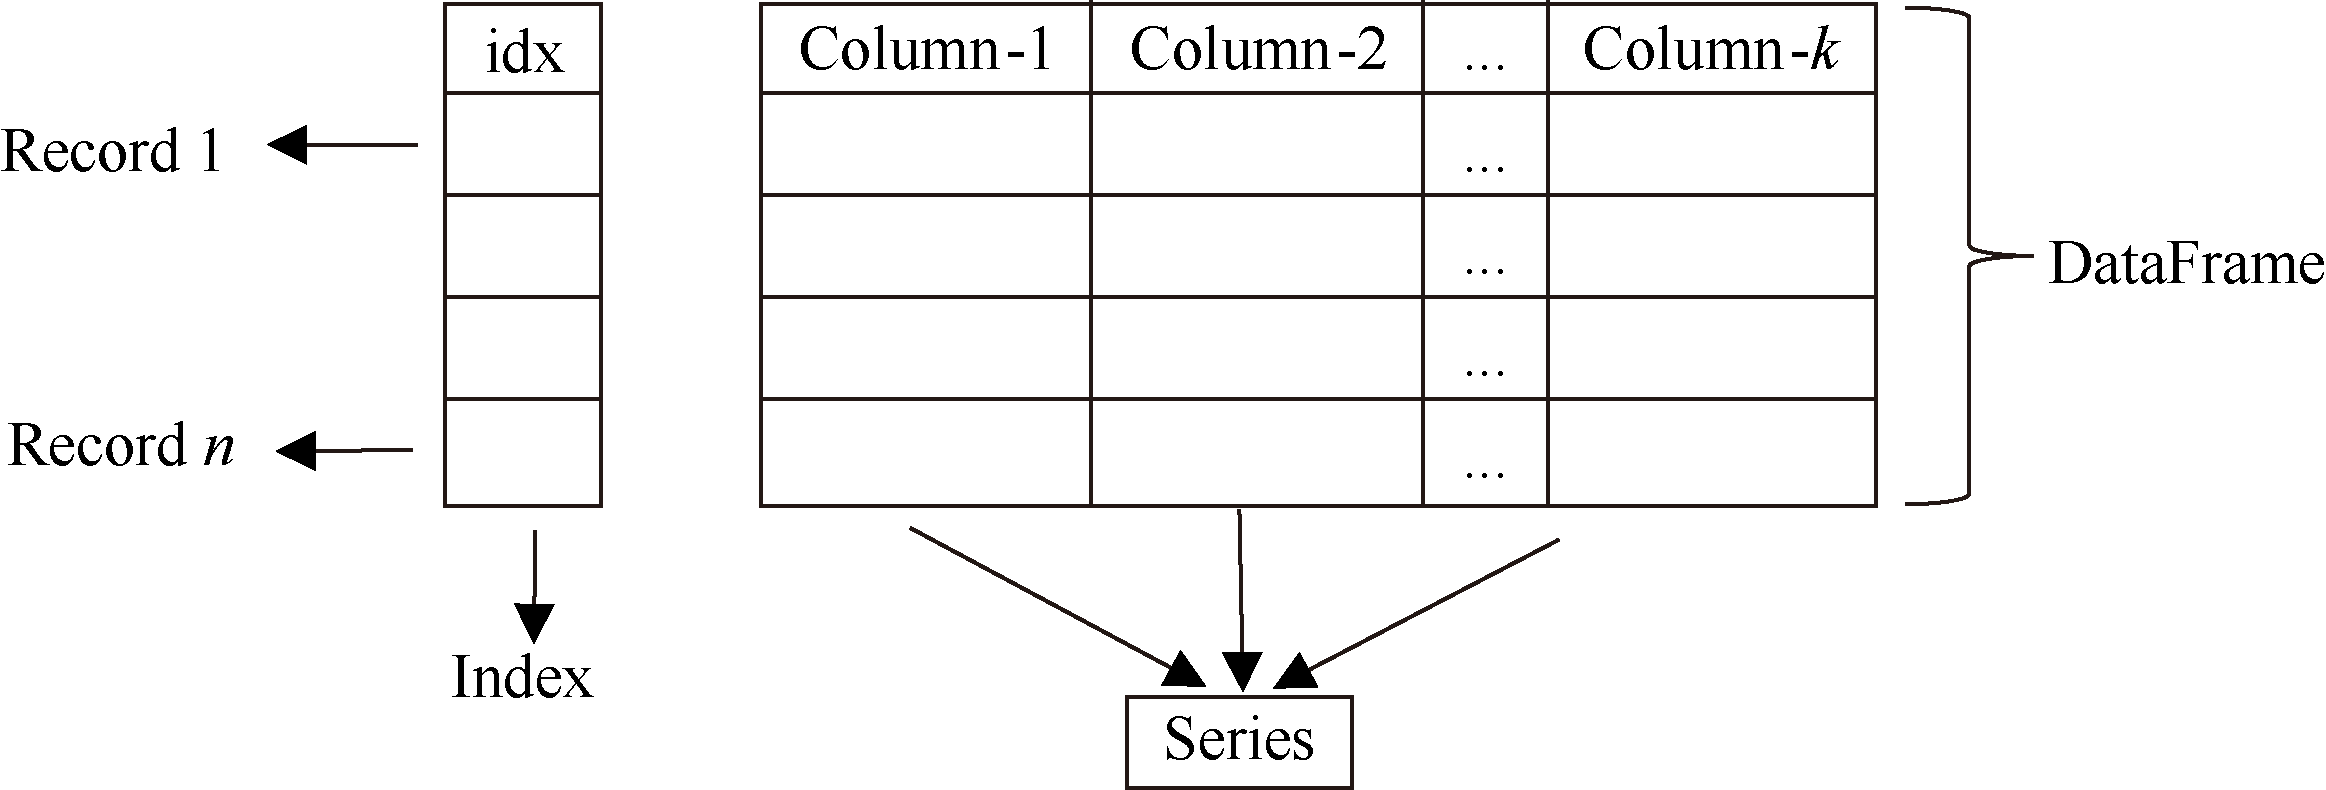

In [14]:
data=[['Java',90],['Algorithm',66],['Python',98]]
df=pd.DataFrame (data, columns=['课程','成绩'])
df

,课程,成绩
0,Java,90
1,Algorithm,66
2,Python,98


<p style="line-height: 1.5;">

**在使用 ndarray 创建 Dataframe 对象时，参数 index 和 columns 的元素个数应分别等于数组的行数与列数。**
如果没有传递索引，则取默认索引 range(n)，n 为数组长度。</p>
示例代码片段如下：

In [17]:
import numpy as np
arr = np.random.randn(3,4)
index_rows = ["周一",'周二','周三']
index_col = ['A','B','C','D']
arr_df = pd.DataFrame(arr,index=index_rows,columns=index_col)
arr_df

,A,B,C,D
周一,0.314734,-0.489851,1.915220,-1.132485
周二,-0.059724,-1.481651,-1.071860,1.918062
周三,-0.326008,0.859092,0.078634,0.808831


<p style="line-height: 1.5;">

我们可以**使用字典（key/value）或字典中嵌套列表的方式创建 DataFrame**，其中字典的值 value 将作为 DataFrame 的数据，键 key 将作为列索引。</p>
<p>
<font color='red' >如果 DataFrame 的部分列没有数据对应（如下述代码片段中的 df1），则表示为缺失值 NaN。</font></p>
<p>示例代码片段如下：

In [18]:
data=[{'课程':'Java','成绩':90},{'课程':'Algorithm','成绩':96},{'课程':'C++'}]
df1=pd.DataFrame(data)
df1

,课程,成绩
0,Java,90.0
1,Algorithm,96.0
2,C++,NaN


#### <font color='blue' >2.2.2.3  DataFrame数据访问</font>
<p style="line-height: 1.5;"> 

在**读取 DataFrame 的列数据**时，有两种最基本的方法。例如，df.课程和 df['课程']都可以查看 df 中的课程：

In [19]:
df['课程']

0         Java
1    Algorithm
2       Python
Name: 课程, dtype: object

<p style="line-height: 1.5;">

在**读取行数据时**，不能像访问列数据一样直接使用 df['行索引']，而是**要借助函数 loc[.] 和 iloc[.] 来读取。**

- 函数 loc[.] 通过行索引 index 的实际值读取行数据，如 loc['A'] 表示读取 index 为"A"的行；
- 函数 iloc[.] 通过顺序数字（行号）读取行数据，如 iloc[0] 表示读取第 1 行数据。

为了明确区分，下述代码片段把数据框 df 的行索引修改为['张三'，'李四'，'王五'，'赵六']：

In [20]:
data={'学生':['张三','李四','王五'],'课程': ['Java','Algorithm','Python'], '成绩':
[90,96,98]}
df=pd.DataFrame(data)
df.set_index('学生', inplace = True)
df

,课程,成绩
学生,,
张三,Java,90
李四,Algorithm,96
王五,Python,98


<p style="line-height: 1.5;">

要**获取学生张三的课程和成绩信息**，下述两种访问方式都可以。数据框df默认的是行索引，loc[.] 和 iloc[.] 的效果是一样的。</p>

**例1. loc[.] 方法：**

In [21]:
df.loc['张三']

课程    Java
成绩      90
Name: 张三, dtype: object

**例2. iloc[.] 方法：**

In [22]:
df.iloc[0]

课程    Java
成绩      90
Name: 张三, dtype: object

<p>接下来是略微复杂的读取示例，分别利用 loc[.] 和 iloc[.] 读取指定行号和列标位置处的数据。</p>
<p>    
 定义一个从 1 到 9 的 3×3 的 DataFrame，命名为 data，如下所示：

In [23]:
data=pd.DataFrame(np.arange(1,10).reshape(3,3), index=list('abc'),columns=list('ABC'))
data

,A,B,C
a,1,2,3
b,4,5,6
c,7,8,9


读取行号为 a、b，列标为 A、B 位置处的数据，或者说读取第 0 和第 1 行中第 0、第 1 列的数据：

In [25]:
data.loc[['a','b'],['A','B']]

,A,B
a,1,2
b,4,5


In [26]:
#或者
data.iloc[[0,1],[0,1]]

,A,B
a,1,2
b,4,5


<p>
    
通过**在函数 loc[.] 中设置参数为逻辑表达式**，可以解决 DataFrame 中利用数值条件访问数据的问题，如读取 A 列中数值为 1，且 B 列中数值为 2 所在行的数据：

In [27]:
data.loc[(data['A']==1) & (data['B']==2)]

,A,B,C
a,1,2,3


#### <font color='blue' >2.2.2.4  行列级批处理</font>
##### <font color='blue' >1．pandas.DataFrame.apply() 函数</font>
 <p style="line-height: 1.5;">
 
当需要对 Series 和 DataFrame 等对象**执行批处理操作**时，pandas.DataFrame.apply() 函数是一个好的选择，其格式如下：

>pandas.DataFrame.apply(self, func, axis=0, raw=False, result_type=None, args=(), \*\*kwds)

其中，func 表示函数，可以是内置函数、第三方函数、自定义函数或匿名函数。
 <font color='red' >func 函数通过 pandas.DataFrame.apply() 可应用于每一行或每一列，默认将列或行作为 Series 对象传递给 apply() 函数，最终返回新的 DataFrame 或 Series。</font>

下述代码片段**展示函数 apply() 的 6 种不同的应用**，其中，变量 df1～df6 的含义如下。

- （1）df1 是 apply() 函数将内置函数 max() 应用于数据框 df 的每一行得出的结果，即每行的最大值。axis 用于设置 func 函数按行还是按列应用，默认按列应用（axis = 0或axis = 'index'），axis = 1 或 axis = 'columns' 表示按行应用。
- （2）df2 是同时传入 numpy.mean() 和 numpy.min() 函数，应用于 df 进行聚合操作的结果。apply() 函数同时传入多个函数时，返回的结果也会聚合成一个新的 DataFrame 或 Series，其作用类似于聚合函数 pandas.DataFrame.agg()，后续内容会详细介绍此函数。
- （3）df3 是 apply() 函数将 Pandas 中的 min() 函数应用于每列得出的最小值。
- （4）df4 使用匿名函数将原数据 df 中的每个元素数值减 1。
- （5）df5 中的函数名以字符串的形式传入，而且不同的列运用不同的函数进行操作，num1 列求最大值，num2 列求最小值。
- （6）df6 是对 num1 和 num2 两列分别进行两种不同的函数操作。

In [28]:
import numpy as np
import pandas as pd
df = pd.DataFrame({'num1': [1, 3, 5], 'num2': [2, 4, 6], 'num3': [10, 8, 7], 'num4': [3, 6, 9]},index=['A', 'B', 'C'])
print(df)
df1 = df.apply(max,axis=1)  # Python的内置函数
print('-' * 30, '\n', df1, sep='')
df2 = df.apply([np.mean,np.min])  # NumPy中的函数
print('-' * 30, '\n', df2, sep='')
df3 = df.apply(pd.DataFrame.min)  # Pandas中的方法
print('-' * 30, '\n', df3, sep='')
df4 = df.apply(lambda x:x-1)
print('-' * 30, '\n', df4, sep='')
df5 = df.apply({'num1': 'max', 'num2': 'min'})
print('-' * 30, '\n', df5, sep='')
df6 = df.apply({'num1': [np.mean, np.median], 'num2': [np.min, np.mean]})
print('-' * 30, '\n', df6, sep='')

   num1  num2  num3  num4
A     1     2    10     3
B     3     4     8     6
C     5     6     7     9
------------------------------
A    10
B     8
C     9
dtype: int64
------------------------------
      num1  num2      num3  num4
mean   3.0   4.0  8.333333   6.0
amin   1.0   2.0  7.000000   3.0
------------------------------
num1    1
num2    2
num3    7
num4    3
dtype: int64
------------------------------
   num1  num2  num3  num4
A     0     1     9     2
B     2     3     7     5
C     4     5     6     8
------------------------------
num1    5
num2    2
dtype: int64
------------------------------
        num1  num2
amin     NaN   2.0
mean     3.0   4.0
median   3.0   NaN


 <p style="line-height: 1.5;">
 
下述代码进一步**介绍 apply() 函数中的 args 参数**。

- 在自定义函数 yes_or_no() 中，s 表示传入的行数据或列数据，由 axis 的值决定是行或列；
- isinstance(s, pd.Series) 用来判断 s 是否是 Series 数据结构，如果返回结果为 True，则按 Series 数据循环输出，否则直接输出 s-answer。

需要注意的是， <font color='red' >args 是传给应用函数 func（此处是yes_or_no()函数）的位置参数，其接收的数据类型为元组，如果只有一个位置参数，则需要加逗号。</font>

In [29]:
def yes_or_no(s, answer):
    if answer != 'yes' and answer != 'no':
        answer = 'yes'
    if isinstance(s, pd.Series):
        return pd.Series(['{}-{}'.format(d, answer) for d in s])
    else:
        return '{}-{}'.format(s, answer)
df7 = df.apply(yes_or_no, args=('yes',))
df7.index = ['A', 'B', 'C']
print('-' * 30, '\n', df7, sep='')
df8 = df.apply(yes_or_no, args=('no',))
print('-' * 30, '\n', df8, sep='')
df9 = df.apply(yes_or_no, args=(0,))
print('-' * 30, '\n', df9, sep='')

------------------------------
    num1   num2    num3   num4
A  1-yes  2-yes  10-yes  3-yes
B  3-yes  4-yes   8-yes  6-yes
C  5-yes  6-yes   7-yes  9-yes
------------------------------
   num1  num2   num3  num4
0  1-no  2-no  10-no  3-no
1  3-no  4-no   8-no  6-no
2  5-no  6-no   7-no  9-no
------------------------------
    num1   num2    num3   num4
0  1-yes  2-yes  10-yes  3-yes
1  3-yes  4-yes   8-yes  6-yes
2  5-yes  6-yes   7-yes  9-yes


##### <font color='blue' >2．pandas.DataFrame.applymap()函数</font>
 <p style="line-height: 1.5;">
 
与 pandas.DataFrame.apply() 函数相同，**pandas.DataFrame.applymap() 和 Series.map() 函数也可以实现批处理**，处理的具体操作由用户传入的 func 函数决定。
pandas.DataFrame.applymap() 函数的格式如下：

>applymap(self, func, na_action=None, \*\*kwargs) 

下述代码片段通过**在函数 applymap() 中传入匿名函数**来对原数据框中所有元素数值加 10，具体方法和 apply() 函数一样：

In [30]:
df = pd.DataFrame({'Col-1': [8, 3, 5], 'Col-2': [2, np.nan, 8], 'Col-3': [np.nan, 8, 7]},index=['X', 'Y', 'Z'])
print(df)
df1 = df.applymap(lambda x: x+10)  # 匿名函数
print('-' * 30, '\n', df1, sep='')

   Col-1  Col-2  Col-3
X      8    2.0    NaN
Y      3    NaN    8.0
Z      5    8.0    7.0
------------------------------
   Col-1  Col-2  Col-3
X     18   12.0    NaN
Y     13    NaN   18.0
Z     15   18.0   17.0


**函数 applymap() 与 apply() 的不同之处：**

- applymap() 函数不支持给 func 传位置参数，因此 func 必须只有一个位置参数，默认接收 DataFrame 中的元素；
- applymap() 函数不能单独按列或按行来操作，只能对 DataFrame 的每个元素做处理；
- applymap() 函数不支持一次传入多个 func 进行聚合处理，也不支持函数名用字符串的方式传入。

## <font color='blue' >2.3　非数值数据转换</font>
<p style="line-height: 1.5;"> 
数据分析中除了数值数据，还会遇到非数值数据。

- 数值数据是指有确定值的数据，在数轴上能找到其对应的点，可以比较大小；
- 非数值数据在数轴上没有确定的点，如文本、类别和时间等数据，这类数据不能比较大小、不能排序，通常需要进行数值化处理后才能用于算法中。

例如，天气是一个具有类属特征的数据，它的属性取值于离散集合 [sunny, cloudy, snowy]。接下来对这类数据进行**数值化处理**。

In [124]:
test_data=pd.read_csv('property-data.csv')
test_data.isnull().head(3)

,PID,ST_NUM,ST_NAME,OWN_OCCUPIED,NUM_BEDROOMS,NUM_BATH,SQ_FT
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,True,False,False,True,False,False


### <font color='blue' >2.3.1  map() 函数</font>
<p style="line-height: 1.5;"> 

下面定义一个字典 wea，并**使用 map() 函数实现非数值到数值的映射：**

In [31]:
df=pd.DataFrame({'weather':['sunny','cloudy','snowy']})
wea={'sunny':1,'cloudy':2,'snowy':3}
df['weather']=df['weather'].map(wea)
df

,weather
0,1
1,2
2,3


### <font color='blue' >2.3.2  One-Hot 编码</font>
<p style="line-height: 1.5;">

在数据分析中，我们会遇到分类特征特别多的数据，如人的性别有男女，来自的国家有中国、英国、法国等。 <font color='red' >这些特征值均是离散的、无序的，需要对其进行特征数字化。</font>**那么，什么是特征数字化呢？**例如，不同特征的离散取值集合如下。</p>

- 性别特征：["男"，"女"]。
- 国家特征：["中国"，"英国"，"法国"]。
- 运动特征：["足球"，"篮球"，"羽毛球"，"乒乓球"]。

<p style="line-height: 1.5;">
假如某个样本（某个人）的特征是“男”“中国”“乒乓球”，则可以用 [0, 0, 3] 来表示，但是这样的编码特征并不能直接用于算法中，因为多数算法是基于向量空间中的度量进行计算的。为了使非偏序关系的变量取值不具有偏序性，并且与原点是等距的，采用 One-Hot 编码是一个很好的选择，其可将离散特征的取值扩展到欧几里得空间，离散特征的某个取值都对应欧几里得空间的某个点。 <font color='red' >将离散型特征使用 One-Hot 编码，会让特征之间的距离计算更加合理，编码后的特征的每一维度都可以看成是连续的。</font></p>

<p style="line-height: 1.5;">

**什么是 One-Hot 编码？**
<p>
    <font color='red' >One-Hot 编码又称一位有效编码，采用 N 位状态寄存器对 N 个状态值进行编码，每个状态都有它独立的寄存器位，并且在任意时刻都只有一位有效。</font></p>
<p>
One-Hot 编码是分类变量作为二进制向量的表示。首先将分类值映射到整数值，然后将每个整数值表示为一个二进制向量，除了在该整数值索引位标记为 1，其他索引位都是 0。</p>
例如，性别特征["男","女"]有两个特征值，N=2，"男"编码为 10，"女"编码为 01。依次类推，国家特征的各状态值分别编码为"中国"（100）、"英国"（010）和"法国"（001）、运动特征的各状态值分别编码为"足球"（1000）、"篮球"（0100）、"羽毛球"（0010）和"乒乓球"（0001）。
<p>
此时，当一个样本为["男","中国","乒乓球"]时，完整的特征数字化结果为 101000001。</p>
<p>
    
下面看一个 **One-Hot 编码的例子**。</p>
<p>下述代码片段中的数据矩阵是 4×3 的，即 4 个数据，3 个特征维度。该数据矩阵的第一列为第一个特征维度，有 2 种取值 0 或 1，对应编码为 10、01；第二列为第二个特征维度，有 3 种取值 0、1 或 2，因此对应编码为 100、010、001；同理，第三列为第三个特征维度，有 4 种取值 0、1、2 或 3，对应编码为 1000、0100、0010、0001。</p>

In [32]:
from sklearn import preprocessing  
enc = preprocessing.OneHotEncoder()  
enc.fit([[0,0,3],[1,1,0],[0,2,1],[1,0,2]])   
#这里使用一个新的数据来进行测试
array = enc.transform([[0,1,3]]).toarray()  
array

F:\place-install\anaconda\lib\site-packages\sklearn\preprocessing\data.py:1961: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  X = check_array(X, dtype=np.int)
F:\place-install\anaconda\lib\site-packages\sklearn\preprocessing\data.py:2023: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use,

array([[1., 0., 0., 1., 0., 0., 0., 0., 1.]])

<details>
    <summary><font color='blue' size='3'>代码解析</font></summary> 
    现要编码的列表为 [0, 1, 3]：
    
- 0 为第一位特征值，编码为 10；
- 1 为第二位特征值，编码为 010；
- 3 为第三位特征值，编码为 0001；

故此编码结果为 100100001。
</details>

## <font color='blue' >2.4　数据清洗</font>
<p style="line-height: 1.5;">
当数据集中存在数据缺失、数据及格式错误或数据重复等情况时，如果要使后续的数据分析更加准确，就需要对这些异常数据进行数据清洗。<font color='red' >数据清洗包括检查数据一致性，以及处理无效值、缺失值和重复值等。</font>本节介绍一些 Pandas 常用的数据清洗方法。

### <font color='blue' >2.4.1  缺失值处理</font>
<p style="line-height: 1.5;">

我们获取的源数据可能会由于信息暂时无法获取、设备故障、人为因素遗漏或丢失等而使数据集中存在**缺失值（NaN），即空值或未填写的数据**。缺失值的存在会使系统中表现出的不确定性更加明显，甚至导致数据挖掘后产生不可靠的输出。<font color='red' >对于缺失值的处理方法通常有删除包含缺失值的行或列，或者使用替换的方法填充缺失值。</font>

#### <font color='blue' >1．缺失值删除
<p style="line-height: 1.5;">
    删除缺失值是一种简单而直接的方法，可以通过 Pandas 中的 DataFrame.dropna() 函数实现，其格式如下：</p>

>DataFrame.dropna(axis=0,how='any',thresh=None,subset=None,inplace=False)

- 函数 DataFrame.dropna() 默认删除整行数据，如果想删除整列数据，则可以设置 axis = 1；
- 参数 how 的默认值为 any，即存在一个缺失值就删除整行或整列，how='all' 表示整行或整列都是缺失值时，才删除整行或整列；
- 参数 thresh 用于设置保留下来的行中至少有多少非空值。

下面以数据集 property-data.csv 为例，**通过 DataFrame.isnull() 函数判断数据集中是否存在空值：**

In [34]:
test_data = pd.read_csv('property-data.csv')
test_data.isnull().head(3)

,PID,ST_NUM,ST_NAME,OWN_OCCUPIED,NUM_BEDROOMS,NUM_BATH,SQ_FT
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,True,False,False,True,False,False


In [35]:
test_data.dropna()

,PID,ST_NUM,ST_NAME,OWN_OCCUPIED,NUM_BEDROOMS,NUM_BATH,SQ_FT
0,100001000.0,104.0,PUTNAM,Y,3,1,1000
1,100002000.0,197.0,LEXINGTON,N,3,1.5,--
8,100009000.0,215.0,TREMONT,Y,na,2,1800


还可以**通过 subset 参数选定列**，仅删除 PID 和 ST_NUM 列中数值为空值的行：

In [126]:
test_data.dropna(subset=['PID','ST_NUM'])

,PID,ST_NUM,ST_NAME,OWN_OCCUPIED,NUM_BEDROOMS,NUM_BATH,SQ_FT
0,100001000.0,104.0,PUTNAM,Y,3,1,1000
1,100002000.0,197.0,LEXINGTON,N,3,1.5,--
3,100004000.0,201.0,BERKELEY,12,1,NaN,700
5,100006000.0,207.0,BERKELEY,Y,NaN,1,800
7,100008000.0,213.0,TREMONT,Y,1,1,NaN
8,100009000.0,215.0,TREMONT,Y,na,2,1800


#### <font color='blue' >2．缺失值替换</font>
<p style="line-height: 1.5;">

删除缺失值是一种非常极端的数据处理方法，极大可能会造成数据丢失，因此用合适的数据替换缺失值是一种很好的数据处理方法。为了消除空值的影响，可以将它们替换为更有意义的数据。</p>

通常**用 fillna() 函数来替换一些空字段**。例如，使用字符串 'ABCD' 替换所有的空值：</p>

In [127]:
test_data. fillna('ABCD')

,PID,ST_NUM,ST_NAME,OWN_OCCUPIED,NUM_BEDROOMS,NUM_BATH,SQ_FT
0,1.00001e+08,104,PUTNAM,Y,3,1,1000
1,1.00002e+08,197,LEXINGTON,N,3,1.5,--
2,1.00003e+08,ABCD,LEXINGTON,N,ABCD,1,850
3,1.00004e+08,201,BERKELEY,12,1,ABCD,700
4,ABCD,203,BERKELEY,Y,3,2,1600
5,1.00006e+08,207,BERKELEY,Y,ABCD,1,800
6,1.00007e+08,ABCD,WASHINGTON,ABCD,2,HURLEY,950
7,1.00008e+08,213,TREMONT,Y,1,1,ABCD
8,1.00009e+08,215,TREMONT,Y,na,2,1800


<p style="line-height: 1.5;">
在实际的数据处理过程中，一般不用这种全量替换的策略，而是通过分析每一列数据的特征或规律，构建一个值进行替换。在 PID 列中，第一行到最后一行数据是等差序列，很显然缺失值应该是 100005000；最后一列SQ_FT表示的是面积大小，通常数值数据中的空值可以使用 median() 和 mean() 函数分别实现对缺失值的中位数填充和平均值填充。</p>

下述代码片段**使用 mode() 函数，用众数替换缺失值：**

In [128]:
test_data['PID']=test_data['PID'].fillna('100005000')
test_data['SQ_FT']=test_data['SQ_FT'].fillna(test_data['SQ_FT'].mode())
test_data.tail(5)


,PID,ST_NUM,ST_NAME,OWN_OCCUPIED,NUM_BEDROOMS,NUM_BATH,SQ_FT
4,100005000,203.0,BERKELEY,Y,3,2,1600
5,1.00006e+08,207.0,BERKELEY,Y,NaN,1,800
6,1.00007e+08,NaN,WASHINGTON,NaN,2,HURLEY,950
7,1.00008e+08,213.0,TREMONT,Y,1,1,950
8,1.00009e+08,215.0,TREMONT,Y,na,2,1800


### <font color='blue' >2.4.2  错误数据替换</font>
<p style="line-height: 1.5;">
数据错误也是很常见的情况之一，我们可以对错误数据进行替换或移除。以 test_data 为例，在 OWN_OCCUPIED 列中，这一列的值应该是 Y 或 N，除了空值 NaN 以外，还有一个错误数据 12，可以把 12 替换成 Y 或 N；同理，NUM_BATH 列中也有一个比较突兀的数据 HURLEY，可以用数值 1 替换。</p>

**利用 loc[.] 函数进行替换**，示例代码片段如下：

In [129]:
test_data.loc[3,'OWN_OCCUPIED']='Y'
test_data.loc[6,'NUM_BATH']='1'
test_data[3:6]

,PID,ST_NUM,ST_NAME,OWN_OCCUPIED,NUM_BEDROOMS,NUM_BATH,SQ_FT
3,1.00004e+08,201.0,BERKELEY,Y,1,NaN,700
4,100005000,203.0,BERKELEY,Y,3,2,1600
5,1.00006e+08,207.0,BERKELEY,Y,NaN,1,800


### <font color='blue' >2.4.3  数据去重</font>
<p style="line-height: 1.5;">  

为了数据集不受重复数据的影响，提升数据集的精确度，需要对数据进行去重处理。数据去重还可以节省内存空间，提高写入性能。我们通常<font color='red' >使用 duplicated() 和 drop_duplicates() 函数来清洗重复数据：</font>

In [130]:
person=pd.DataFrame({"name": ['Tom', 'Wood', 'James', 'Wood'],"age": [20, 30, 20, 30]})
person

,name,age
0,Tom,20
1,Wood,30
2,James,20
3,Wood,30


数据框 person 中的第 2 行和第 4 行是重复的。<font color='red' >函数 duplicated() 可以判断有无重复值，若返回值为 True，则说明存在重复值；若返回值为 False，则说明无重复值。</font>示例代码片段如下：

In [131]:
person.duplicated()

0    False
1    False
2    False
3     True
dtype: bool

当判断出数据集中存在重复值时，可以**通过 drop_duplicates() 函数删除重复项**，其格式如下：

>DataFrame.drop_duplicates(subset=None, keep='first', inplace=False)

- subset 参数的值可为列名或列名序列，表示只用某些列来识别重复项，默认使用数据集中的所有列来识别。
- 参数 keep 的默认值为 'first'，表示仅保留第一次出现的重复项；若其值为 'last'，则表示仅保留最后一次出现的重复项；若 keep = False，则删除所有重复项。

**删除 person 中重复项的代码片段如下：**

In [132]:
person.drop_duplicates()

,name,age
0,Tom,20
1,Wood,30
2,James,20


接下来，通过设置 subset=['age']，**根据 age 列的重复项删除数据：**

In [133]:
person.drop_duplicates(subset=['age'],keep = 'last')

,name,age
2,James,20
3,Wood,30


### <font color='blue' >2.4.4  数据合并连接</font>

#### <font color='blue' >2.4.4.1  pandas.concat()</font>
<p style="line-height: 1.5;"> 
在数据处理过程中，我们会遇到<font color='red' >对多个表进行拼接合并的需求，pandas.concat() 函数可以实现该需求</font>，其格式如下：</p>

>pandas.concat(objs,axis=0,join='outer',ignore_index=False,keys=None,levels=None)

- 参数 axis 默认为 0，表示纵向连接；若 axis=1，则表示横向连接，称之为并置轴。
- ignore_index 是布尔类型参数，其默认值为 False。如果设置 ignore_index = True，则表示不使用并置轴上的索引，返回结果在并置轴上重标记为（0, 1,…, n-1），这对于并置轴上没有意义的索引信息将非常有用。注意：其他轴上的索引不受影响。

下面创建 3 个 DataFrame 实例，分别是 person1、person2 和 choose：

In [134]:
person1=pd.DataFrame({"id": ['101', '102', '103'],"name": ['Bob', 'Allen', 'Blake']})
print("person1：\n",person1)
person2=pd.DataFrame({"id": ['104', '105'],"name": ['Gage','Chris']})
print("person2：\n",person2)
choose=pd.DataFrame({"name": ['Bob','Blake','Allen','Gage'],"lesson":['Java','Python','C++','Matlab']})
print("choose：\n",choose)

person1：
     id   name
0  101    Bob
1  102  Allen
2  103  Blake
person2：
     id   name
0  104   Gage
1  105  Chris
choose：
     name  lesson
0    Bob    Java
1  Blake  Python
2  Allen     C++
3   Gage  Matlab


**将 person1 和 person2 纵向拼接**，并重置索引。示例代码片段如下：

In [135]:
new_person=pd.concat([person1,person2],ignore_index = True)
print(new_person)

    id   name
0  101    Bob
1  102  Allen
2  103  Blake
3  104   Gage
4  105  Chris


将拼接好的 new_person 与数据框 choose 进行横向拼接。
<p>
    <font color='red' >在进行横向拼接时，函数会自动选择“主键”进行匹配，能匹配上就进行连接，匹配不上就显示为空值 NaN。</font></p>
 示例代码片段如下：

In [136]:
pd.concat([new_person,choose],axis=1)

,id,name,name,lesson
0,101,Bob,Bob,Java
1,102,Allen,Blake,Python
2,103,Blake,Allen,C++
3,104,Gage,Gage,Matlab
4,105,Chris,NaN,NaN


<p style="line-height: 1.5;">

函数 pandas.concat() 中的 **join 参数表示连接方式**。在上述代码片段中，<font color='red' >默认 join='outer'，即对两个数据框进行外连接，可理解为取并集；当设置 join='inner'时，表示内连接，可理解为取交集。</font></p>
<p>
示例代码片段如下：

In [137]:
pd.concat([new_person,choose],axis=1,join='inner')

,id,name,name,lesson
0,101,Bob,Bob,Java
1,102,Allen,Blake,Python
2,103,Blake,Allen,C++
3,104,Gage,Gage,Matlab


#### <font color='blue' >2.4.4.2  pandas.merge()
<p style="line-height: 1.5;"> 
<font color='red' >Pandas 的基本特性之一就是高性能的内存式数据连接（join）与合并（merge）操作。</font>
pandas.merge() 函数实现了这种类型的连接，其格式如下：

>pandas.merge (left,right,how='inner',on=None,left_on=None,right_on=None...)

- 参数 how 表示数据框的连接方式，其默认值为 'inner'，也可以选择 'outer'、'left' 和 'right' 等方式；
- 参数 on 是用于连接的列名，如果未指定，则以左右数据集中列名的交集作为连接键。

首先创建 3 个 DataFrame，分别为 student_info（学生信息）、lesson_info（课程信息） 和 score_info（成绩信息）：

In [138]:
student_info=pd.DataFrame({
    "学号": [202301, 202302, 202303, 202304],
    "姓名": ['小刘', '小张', '小王', '小李']})
print("student_info:\n",student_info)
print("\n")
lesson_info=pd.DataFrame({
    "课程号":['A0101','A0102','A0103','A0104','A0105'],
    "课程名":['机器学习','数据库','数据结构','python程序设计','数据科学导论']})
print("lesson_info:\n",lesson_info)
print("\n")
score_info=pd.DataFrame({
    "学号":[202301,202301,202302,202302,202303,202304],
    "课程号":['A0103','A0102','A0103','A0104','A0105','A0105'],
    "成绩":[88,91,92,95,87,93]})
print("score_info:\n",score_info)

student_info:
        学号  姓名
0  202301  小刘
1  202302  小张
2  202303  小王
3  202304  小李


lesson_info:
      课程号         课程名
0  A0101        机器学习
1  A0102         数据库
2  A0103        数据结构
3  A0104  python程序设计
4  A0105      数据科学导论


score_info:
        学号    课程号  成绩
0  202301  A0103  88
1  202301  A0102  91
2  202302  A0103  92
3  202302  A0104  95
4  202303  A0105  87
5  202304  A0105  93


student_info 和 score_info **通过'学号'字段进行拼接**，将学生的详细信息和成绩放在一个 DataFrame 中，将其命名为 chengji：

In [139]:
chengji=pd.merge(student_info,score_info,on='学号')
chengji


,学号,姓名,课程号,成绩
0,202301,小刘,A0103,88
1,202301,小刘,A0102,91
2,202302,小张,A0103,92
3,202302,小张,A0104,95
4,202303,小王,A0105,87
5,202304,小李,A0105,93


<p><font color='red' >相较于 pandas.concat() 函数，pandas.merge() 函数完成连接后不会出现相同的列名</font>，但两个函数的原理一致。</p>
chengji 与 lesson_info 按'课程号'列进行连接的代码片段如下：

In [140]:
info_chengji=pd.merge(chengji,lesson_info,on='课程号',how='left')
info_chengji 

,学号,姓名,课程号,成绩,课程名
0,202301,小刘,A0103,88,数据结构
1,202301,小刘,A0102,91,数据库
2,202302,小张,A0103,92,数据结构
3,202302,小张,A0104,95,python程序设计
4,202303,小王,A0105,87,数据科学导论
5,202304,小李,A0105,93,数据科学导论


- how='left' 表示以左表数据为准，右表中无对应数据就填充 NaN，此时左表中数据在连接后一定是全的；
- 当设置 how='right' 时，右表中数据在连接后一定是全的。
- 在 pandas.merge() 函数中，写在前面的为左表，写在后面的为右表。

### <font color='blue' >2.4.5  数据分组及聚合</font>
<p style="line-height: 1.5;"> 
简单的累计方法可以让我们更好地理解数据集，迅速地获取有用信息。我们经常需要对某些标签或索引的局部进行累计分析。例如，在电商行业中，将全国的总销售额根据省份进行划分，分析各省份销售额的变化情况；在社交领域，将用户根据画像（性别、年龄）进行细分，研究用户的偏好等，这时就需要用到分组。</p>
<p style="line-height: 1.5;"> 
分组根据某个（多个）字段划分为不同的群体，其流程可表述为分割、应用和组合，如图2-5所示。</p>

[](attachment:image2-5.png)
<img src = attachment:image2-5.png width=300>

<div style="text-align: center;">图2-5 分组理念</div>

<p style="line-height: 1.5;"> 
<font color='red' >函数 pandas.groupby() 首先将 DataFrame 按照某个字段进行分割，将该字段中相等的值所在行（列）划分为一组；然后对分割后的各组执行相应的变换操作；最后输出汇总变换后的各组结果。</font></p>
<p style="line-height: 1.5;"> 
pandas.groupby() 函数的格式如下：

>pandas.groupby(by=None, axis=0, as_index=True, sort=True,dropna=True......)

- dropna 参数的默认值为 True，若分组键中包含 NaN，则删除 NaN 及其所在行或列；
- 若 dropna=False，则 NaN 将被视为组合键的值。

新建数据框 df，示例代码片段如下：
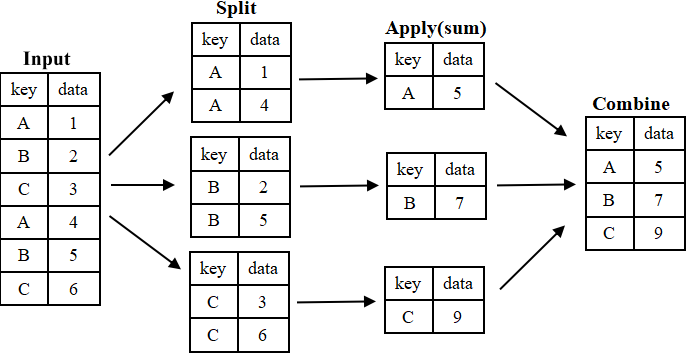

In [142]:
df=pd.DataFrame({
    '班级':['A','B','A','B'],
    '姓名':['小张','小王','小刘','小赵'],
    '语文':[88,87,96,85],
    '数学':[92,90,95,85]})
df

,班级,姓名,语文,数学
0,A,小张,88,92
1,B,小王,87,90
2,A,小刘,96,95
3,B,小赵,85,85


接下来**统计各个班级中每门课程的平均分**。首先按'班级'进行分组，计算每门课程的平均值，然后通过 as_index 参数重置索引：

In [143]:
df.groupby('班级',as_index=False).mean()

,班级,语文,数学
0,A,92.0,93.5
1,B,86.0,87.5


**agg() 聚合操作是分组后的常见操作。**下述代码片段对数据表中的两门课程分别统计班级的平均分、最低分和最高分：

In [144]:
df.groupby('班级').agg([np.mean,min,max])

语文            数学        
   mean min max  mean min max
班级                           
A    92  88  96  93.5  92  95
B    86  85  87  87.5  85  90

<p style="line-height: 1.5;"> 
<font color='red' >agg() 聚合操作可以用来求和、求均值、求最大值或最小值等。</font>表2-4列出了 Pandas DataFrame 中常见的聚合函数及其用途。</p>

<div style="text-align: center;">表2-4  Pandas 中常见的聚合函数及其用途</div>

| 函数 | 用途 |
|:--- |:--- |
| min()|求最小值 |
|max()|求最大值|
|sum()|求和|
|mean()|求均值|
|median()|求中位数|
|std()|求标准差|
|var()|求方差|
|count()|计数|

## <font color='blue' >2.5  本章小结</font>
<p style="line-height: 1.5;"> 
NumPy 和 Pandas 是 Python 中最受欢迎的数据科学与分析库之一，NumPy 提供了高性能的多维数组和矩阵计算功能，而 Pandas 则提供了高效的数据结构（Series和DataFrame）。</p>
<p>本章通过实例详细介绍了 NumPy 和 Pandas 所提供的主要的数据预处理功能与操作，包括非数值数据转换、缺失值处理、错误数据替换、重复值处理、数据合并连接、数据分组及聚合等。</p>